# EDA Questions and Answers

This notebook delivers a structured exploratory data analysis of four verified datasets:

- **Australian university enrollments** (2016–2024, 11 discipline categories)
- **Australian Commonwealth funding allocations** (2019–2026, field-of-education level)
- **UK university enrollments** (2013–2025, regional breakdown)
- **Employment by industry** (2005–2025, quarterly)

Each question is answered with targeted statistical methods and at most **three visualisations**. Where appropriate, tests report effect sizes alongside p-values, and model fit is compared across specifications.

**Policy context — Job-Ready Graduates (JRG) package**: From 2021, the Australian Government restructured Commonwealth contributions and student fee caps by discipline — increasing costs for humanities and law while reducing them for teaching, nursing, IT, and agriculture. Vertical red dashed lines on time-series plots mark this 2021 inflection point.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.labelsize': 10})

# ── Paths ──────────────────────────────────────────────────────────────────────
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
if clean_dir is None:
    raise FileNotFoundError(f'Could not locate data/clean from: {Path.cwd()}')

# ── AUS Enrollments ────────────────────────────────────────────────────────────
ause = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
aus_year_cols = [col for col in ause.columns if str(col).isdigit()]
for col in aus_year_cols:
    ause[col] = pd.to_numeric(ause[col], errors='coerce')

aus_long = (ause
    .melt(id_vars=[c for c in ause.columns if c not in aus_year_cols],
          value_vars=aus_year_cols, var_name='Year', value_name='Enrollments')
    .assign(Year=lambda d: pd.to_numeric(d['Year']).astype(int))
    .query("Category != 'Total'")
    .dropna(subset=['Year', 'Enrollments'])
    .copy()
)

# ── AUS Funding ────────────────────────────────────────────────────────────────
funding = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')
funding['Year'] = pd.to_numeric(funding['Year'], errors='coerce').astype(int)
for col in ['MaximumStudentContribution', 'CommonwealthContribution']:
    funding[col] = pd.to_numeric(funding[col], errors='coerce')
funding['TotalFunding'] = funding['MaximumStudentContribution'] + funding['CommonwealthContribution']
funding_grouped = funding.groupby(['Year', 'Category', 'CategoryKey'], as_index=False)[
    ['MaximumStudentContribution', 'CommonwealthContribution', 'TotalFunding']
].sum()

# ── UK Enrollments ─────────────────────────────────────────────────────────────
uk = pd.read_csv(
    clean_dir / 'uk_grouped' / 'with_categorykey' / 'with_category_name' /
    'UK_enrollments_grouped_comparison_all_years_with_category.csv'
)
for col in ['categorykey', 'England', 'Wales', 'Scotland', 'Northern Ireland', 'Other UK', 'Total UK']:
    if col in uk.columns:
        uk[col] = pd.to_numeric(uk[col], errors='coerce')
uk['Year'] = uk['AcademicYear'].astype(str).apply(
    lambda s: int(s.split('/')[0]) if '/' in s else int(float(s))
)
uk_long = uk[uk['Category'] != 'Total'].dropna(subset=['Year', 'Total UK']).copy()

# ── Employment ─────────────────────────────────────────────────────────────────
emp = pd.read_csv(clean_dir / 'employment_by_industry_20y+keys.csv')
id_cols = [c for c in ['Industry', 'Category', 'CategoryKey'] if c in emp.columns]
period_cols = [c for c in emp.columns if c not in id_cols]
for col in period_cols:
    emp[col] = pd.to_numeric(emp[col], errors='coerce')

employment_long = emp.melt(id_vars=id_cols, value_vars=period_cols,
                            var_name='PeriodLabel', value_name='Employment')
# Try both 2-digit and 4-digit year formats
employment_long['Period'] = pd.to_datetime(employment_long['PeriodLabel'], format='%b-%y', errors='coerce')
mask_failed = employment_long['Period'].isna()
if mask_failed.any():
    employment_long.loc[mask_failed, 'Period'] = pd.to_datetime(
        employment_long.loc[mask_failed, 'PeriodLabel'], format='%b-%Y', errors='coerce'
    )
employment_long['Year'] = employment_long['Period'].dt.year
employment_long = employment_long.dropna(subset=['Period', 'Employment']).copy()

# ── Merged AUS frame ───────────────────────────────────────────────────────────
analysis_merged = pd.merge(
    aus_long[['Category', 'CategoryKey', 'Year', 'Enrollments']],
    funding_grouped,
    on=['Category', 'CategoryKey', 'Year'],
    how='inner',
)

JRG_YEAR = 2021  # Job-Ready Graduates policy commencement

print('Datasets loaded successfully.')
print(f'  AUS enrollments : {len(aus_long):,} rows | years {aus_long["Year"].min()}–{aus_long["Year"].max()}')
print(f'  AUS funding     : {len(funding_grouped):,} rows | years {funding_grouped["Year"].min()}–{funding_grouped["Year"].max()}')
print(f'  UK enrollments  : {len(uk_long):,} rows | years {uk_long["Year"].min()}–{uk_long["Year"].max()}')
print(f'  Employment      : {len(employment_long):,} rows | years {int(employment_long["Year"].min())}–{int(employment_long["Year"].max())}')
print(f'  Merged AUS frame: {len(analysis_merged):,} rows')

Datasets loaded successfully.
  AUS enrollments : 99 rows | years 2016–2024
  AUS funding     : 88 rows | years 2019–2026
  UK enrollments  : 246 rows | years 2013–2024
  Employment      : 1,518 rows | years 2005–2025
  Merged AUS frame: 66 rows


## 1. How have enrollment and employment levels changed over time across categories?

Australian total enrollments grew from approximately 1.47 million in 2016 to 1.62 million in 2024 — a cumulative gain of ~10% — but the composition shifted materially. **Information Technology** leads with ~38–40% cumulative growth (CAGR ≈ 4%); **Health** and **Education** also outpace the aggregate. **Creative Arts** and **Society & Culture** declined relative to their 2016 baselines, particularly after 2020. The JRG package (2021) coincides with a visible inflection in multiple STEM and Health categories.

UK enrollments show a comparable upward trend, with a brief 2020 dip before resuming growth. Employment in aggregate grew strongly over 20 years, with Health the dominant and fastest-growing category.

Three visualisations: **(1)** a category-level growth index (AUS, rebased to first available year) to compare relative momentum; **(2)** a stacked area chart showing compositional evolution of AUS enrollments; **(3)** a year-on-year percentage change heatmap isolating acceleration and deceleration.

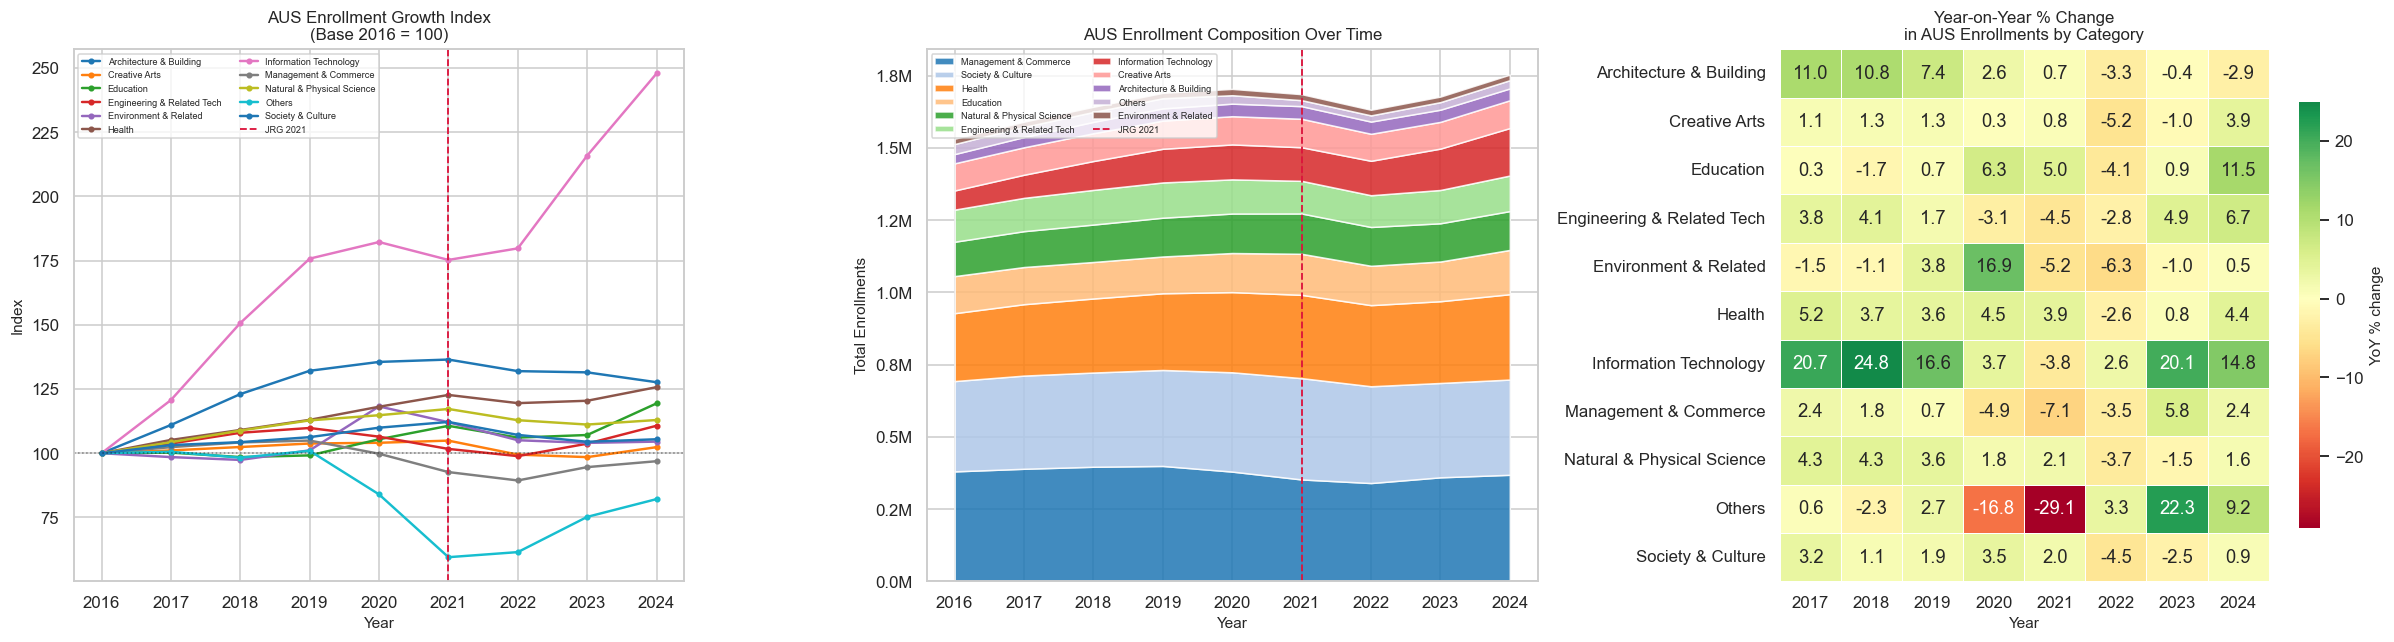

**Table 1.1 — AUS Enrollment Growth by Category**

,First Year,Last Year,Cumulative %,CAGR %
Category,,,,
Information Technology,66355,164464,147.9,12.01
Architecture & Building,32074,40942,27.6,3.10
Health,235033,295498,25.7,2.90
Education,128277,153177,19.4,2.24
Natural & Physical Science,119102,134511,12.9,1.53
Engineering & Related Tech,111060,122954,10.7,1.28
Society & Culture,312569,329590,5.4,0.67
Environment & Related,18537,19376,4.5,0.55
Creative Arts,93916,96142,2.4,0.29


In [2]:
# ── Build category pivot ───────────────────────────────────────────────────────
cat_pivot = aus_long.pivot_table(
    index='Year', columns='Category', values='Enrollments', aggfunc='sum'
).sort_index()

base_vals = cat_pivot.iloc[0]
cat_index = (cat_pivot.div(base_vals)) * 100
yoy_pct = cat_pivot.pct_change() * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ── Plot 1: Growth index by category ──────────────────────────────────────────
pal = sns.color_palette('tab10', n_colors=cat_index.shape[1])
for i, cat in enumerate(cat_index.columns):
    axes[0].plot(cat_index.index, cat_index[cat], label=cat,
                 marker='o', markersize=3, linewidth=1.6, color=pal[i % len(pal)])
axes[0].axhline(100, color='black', linestyle=':', alpha=0.4, linewidth=1)
axes[0].axvline(JRG_YEAR, color='crimson', linestyle='--', linewidth=1.2, label='JRG 2021')
axes[0].set_title(f'AUS Enrollment Growth Index\n(Base {cat_pivot.index[0]} = 100)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Index')
axes[0].legend(fontsize=6, ncol=2)

# ── Plot 2: Stacked area chart ─────────────────────────────────────────────────
cat_order = cat_pivot.mean().sort_values(ascending=False).index.tolist()
fill_colors = sns.color_palette('tab20', n_colors=len(cat_order))
axes[1].stackplot(
    cat_pivot.index,
    [cat_pivot[c].fillna(0).values for c in cat_order],
    labels=cat_order, colors=fill_colors, alpha=0.85
)
axes[1].axvline(JRG_YEAR, color='crimson', linestyle='--', linewidth=1.2, label='JRG 2021')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].set_title('AUS Enrollment Composition Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Enrollments')
axes[1].legend(fontsize=6, loc='upper left', ncol=2)

# ── Plot 3: YoY % change heatmap ───────────────────────────────────────────────
hm_data = yoy_pct.T.dropna(axis=1, how='all')
sns.heatmap(
    hm_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.4, ax=axes[2],
    cbar_kws={'label': 'YoY % change', 'shrink': 0.8}
)
axes[2].set_title('Year-on-Year % Change\nin AUS Enrollments by Category')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# ── CAGR summary ───────────────────────────────────────────────────────────────
n_years = cat_pivot.shape[0] - 1
first_last = pd.DataFrame({
    'First Year': cat_pivot.iloc[0],
    'Last Year': cat_pivot.iloc[-1],
})
first_last['Cumulative %'] = (
    (first_last['Last Year'] - first_last['First Year']) / first_last['First Year'] * 100
).round(1)
first_last['CAGR %'] = (
    ((first_last['Last Year'] / first_last['First Year']) ** (1 / n_years) - 1) * 100
).round(2)
display(Markdown('**Table 1.1 — AUS Enrollment Growth by Category**'))
display(first_last.sort_values('Cumulative %', ascending=False))

## 2. Which categories consistently show the highest and lowest values?

Rankings diverge markedly between funding and enrollment, revealing a structural mismatch that is a deliberate feature of the JRG policy. **Management & Commerce** dominates enrollment but receives the lowest Commonwealth funding per category — reflecting the policy's intent to redirect subsidies toward national-priority fields. Conversely, **Engineering & Related Technology** and **Health** attract the highest Commonwealth contributions but sit mid-table in raw enrollment counts.

Employment rankings align more closely with funding than with enrollment: Health, Architecture & Building, and Natural & Physical Science top both, suggesting that funding allocation partly tracks labour-market demand. The Spearman rank correlation between AUS enrollment rank and funding rank quantifies this misalignment.

Three visualisations: **(1)** a row-normalised heatmap of AUS enrollment intensity by category and year; **(2)** a slopegraph comparing category ranks across enrollment, funding, and employment; **(3)** a normalised median bar chart for cross-dataset comparison.

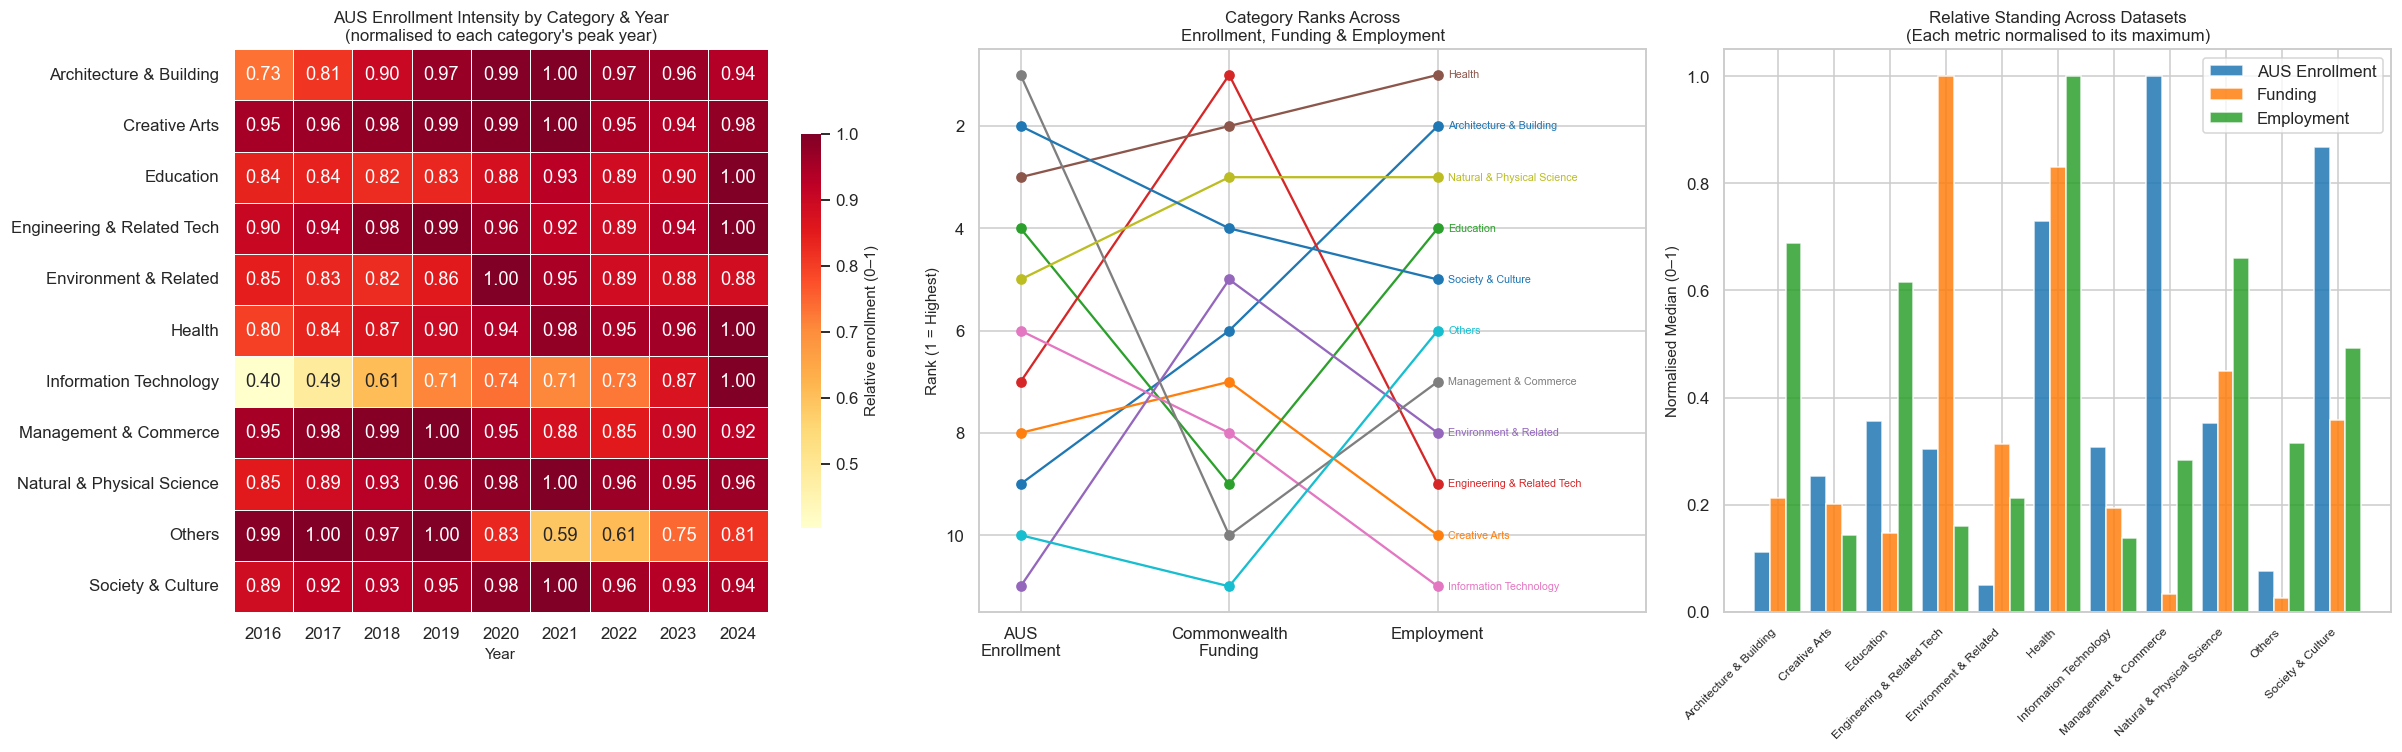

**Table 2.1 — Spearman Rank Correlations Between Datasets**

,Pair,Spearman ρ,p-value,Interpretation
0,AUS Enrollment rank vs Funding rank,0.082,0.8110,Negative = high-enrollment fields receive low ...
1,AUS Enrollment rank vs Employment rank,0.273,0.4171,Positive = enrollment and employment scales pa...


In [3]:
# ── Compute medians and ranks ──────────────────────────────────────────────────
aus_med = aus_long.groupby('Category')['Enrollments'].median()
fund_med = funding_grouped.groupby('Category')['CommonwealthContribution'].median()
emp_med = employment_long.groupby('Category')['Employment'].median()

aus_rank = aus_med.rank(ascending=False).rename('AUS Enrollment')
fund_rank = fund_med.rank(ascending=False).rename('Funding')
emp_rank = emp_med.rank(ascending=False).rename('Employment')
rank_df = pd.concat([aus_rank, fund_rank, emp_rank], axis=1).dropna()

rho_ef, p_ef = stats.spearmanr(rank_df['AUS Enrollment'], rank_df['Funding'])
rho_ee, p_ee = stats.spearmanr(rank_df['AUS Enrollment'], rank_df['Employment'])

# ── Category pivot for heatmap ─────────────────────────────────────────────────
cat_pivot = aus_long.pivot_table(
    index='Year', columns='Category', values='Enrollments', aggfunc='sum'
).sort_index()
row_norm = cat_pivot.div(cat_pivot.max()).T

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: Row-normalised heatmap ─────────────────────────────────────────────
sns.heatmap(
    row_norm, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4,
    ax=axes[0], cbar_kws={'label': 'Relative enrollment (0–1)', 'shrink': 0.7}
)
axes[0].set_title('AUS Enrollment Intensity by Category & Year\n(normalised to each category\'s peak year)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('')

# ── Plot 2: Slopegraph of ranks ────────────────────────────────────────────────
dataset_labels = ['AUS\nEnrollment', 'Commonwealth\nFunding', 'Employment']
x_positions = [0, 1, 2]
pal = sns.color_palette('tab10', n_colors=len(rank_df))
for i, (cat, row) in enumerate(rank_df.iterrows()):
    ranks = [row['AUS Enrollment'], row['Funding'], row['Employment']]
    axes[1].plot(x_positions, ranks, marker='o', markersize=6,
                 label=cat, color=pal[i % len(pal)], linewidth=1.5)
    axes[1].annotate(cat, xy=(2.05, row['Employment']), fontsize=7,
                     va='center', ha='left', color=pal[i % len(pal)])
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(dataset_labels)
axes[1].invert_yaxis()
axes[1].set_ylabel('Rank (1 = Highest)')
axes[1].set_title('Category Ranks Across\nEnrollment, Funding & Employment')
axes[1].set_xlim(-0.2, 3.0)

# ── Plot 3: Normalised median grouped bar ──────────────────────────────────────
norm_df = pd.DataFrame({
    'AUS Enrollment': aus_med / aus_med.max(),
    'Funding': fund_med / fund_med.max(),
    'Employment': emp_med / emp_med.max(),
}).loc[rank_df.index]

x = np.arange(len(norm_df))
width = 0.28
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for j, (label, col) in enumerate(norm_df.items()):
    axes[2].bar(x + j * width, col.values, width, label=label,
                color=bar_colors[j], alpha=0.85, edgecolor='white')
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(norm_df.index, rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Normalised Median (0–1)')
axes[2].set_title('Relative Standing Across Datasets\n(Each metric normalised to its maximum)')
axes[2].legend()

plt.tight_layout()
plt.show()

display(Markdown('**Table 2.1 — Spearman Rank Correlations Between Datasets**'))
display(pd.DataFrame({
    'Pair': ['AUS Enrollment rank vs Funding rank', 'AUS Enrollment rank vs Employment rank'],
    'Spearman ρ': [round(rho_ef, 3), round(rho_ee, 3)],
    'p-value': [round(p_ef, 4), round(p_ee, 4)],
    'Interpretation': [
        'Negative = high-enrollment fields receive low funding (JRG design intent)',
        'Positive = enrollment and employment scales partially aligned',
    ]
}))

## 3. Are the data evenly distributed, or are they skewed?

All four datasets exhibit **positive (right) skewness**: a few large categories dominate each metric while many others cluster at lower values. This means the mean overstates what is typical, and the median is the more appropriate measure of central tendency. Formal Shapiro-Wilk normality tests reject normality for most categories within AUS enrollments (given only 9 data points per category, small-sample power is limited, but combined with high skewness this supports non-parametric methods).

Within-category distributions are generally less skewed than the pooled cross-sectional distribution, indicating that most skew arises from **between-category differences** rather than within-category volatility. This is an important nuance for modelling.

Three visualisations: **(1)** violin plots of AUS enrollment by category, revealing within-category shape; **(2)** pooled distribution comparison (histogram + KDE) across all three datasets; **(3)** Shapiro-Wilk p-value heatmap by category.

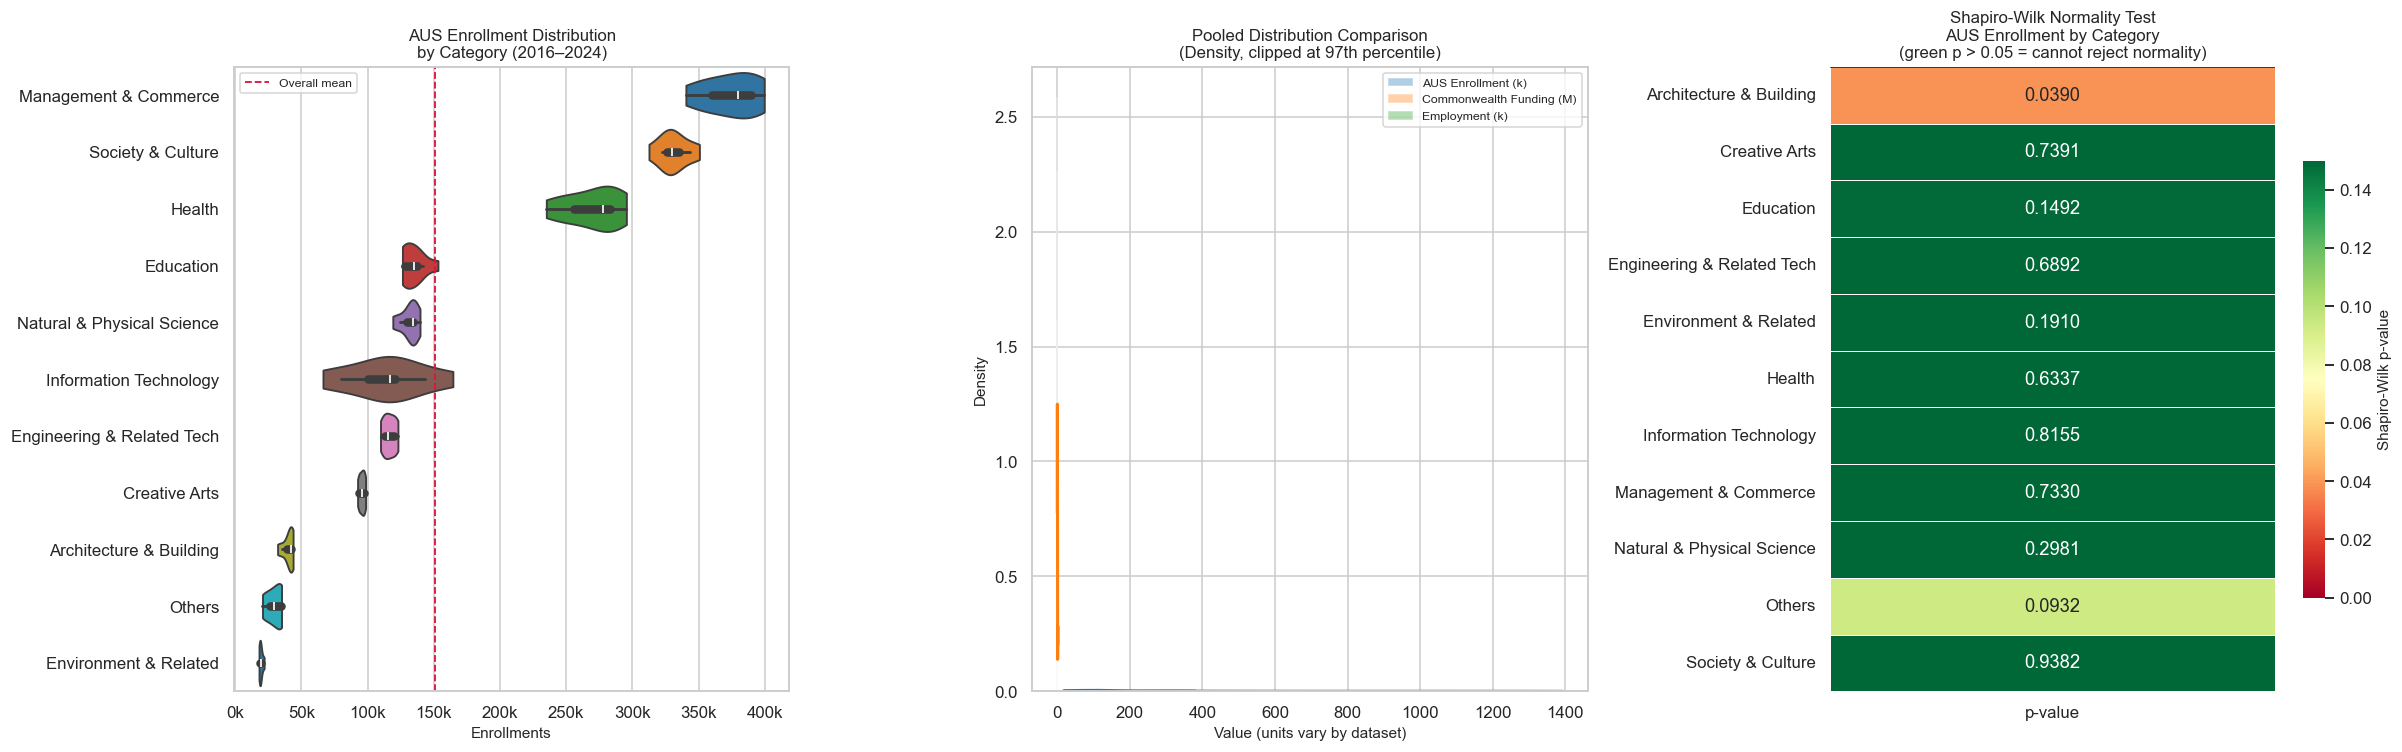

**Table 3.1 — Distributional Shape of Key Variables**

,Dataset,Mean,Median,Skewness,Excess Kurtosis
0,AUS Enrollment,150645.051,119909.0,0.787,-0.685
1,Commonwealth Funding,504796.125,333279.0,1.150,0.208
2,Employment,637260.079,499950.0,0.960,0.833


In [4]:
from scipy.stats import gaussian_kde

cat_order = (aus_long.groupby('Category')['Enrollments']
             .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: Violin plots by category ──────────────────────────────────────────
sns.violinplot(
    data=aus_long, x='Enrollments', y='Category', order=cat_order,
    palette='tab10', inner='box', ax=axes[0], orient='h', cut=0
)
axes[0].axvline(aus_long['Enrollments'].mean(), color='crimson',
                linestyle='--', linewidth=1.2, label='Overall mean')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[0].set_title('AUS Enrollment Distribution\nby Category (2016–2024)')
axes[0].set_xlabel('Enrollments')
axes[0].set_ylabel('')
axes[0].legend(fontsize=8)

# ── Plot 2: Pooled distribution comparison ─────────────────────────────────────
datasets = {
    'AUS Enrollment (k)': aus_long['Enrollments'] / 1e3,
    'Commonwealth Funding (M)': funding_grouped['CommonwealthContribution'] / 1e6,
    'Employment (k)': employment_long['Employment'] / 1e3,
}
colors_d = ['#1f77b4', '#ff7f0e', '#2ca02c']
for (label, series), color in zip(datasets.items(), colors_d):
    data = series.dropna()
    clip_val = data.quantile(0.97)
    data_clipped = data[data <= clip_val]
    axes[1].hist(data_clipped, bins=20, density=True, alpha=0.35, color=color, label=label)
    kde = gaussian_kde(data_clipped)
    xr = np.linspace(data_clipped.min(), data_clipped.max(), 200)
    axes[1].plot(xr, kde(xr), linewidth=2, color=color)
axes[1].set_title('Pooled Distribution Comparison\n(Density, clipped at 97th percentile)')
axes[1].set_xlabel('Value (units vary by dataset)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# ── Plot 3: Shapiro-Wilk p-values heatmap ─────────────────────────────────────
sw_rows = {}
for cat, grp in aus_long.groupby('Category'):
    vals = grp['Enrollments'].dropna().values
    if len(vals) >= 3:
        stat, p = stats.shapiro(vals)
        sw_rows[cat] = {'W': round(stat, 4), 'p-value': round(p, 4)}
sw_df = pd.DataFrame(sw_rows).T
pval_df = sw_df[['p-value']].astype(float)

sns.heatmap(
    pval_df, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=0.15,
    linewidths=0.5, ax=axes[2], cbar_kws={'label': 'Shapiro-Wilk p-value', 'shrink': 0.7}
)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Shapiro-Wilk Normality Test\nAUS Enrollment by Category\n(green p > 0.05 = cannot reject normality)')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# ── Skewness and kurtosis summary ─────────────────────────────────────────────
display(Markdown('**Table 3.1 — Distributional Shape of Key Variables**'))
display(pd.DataFrame({
    'Dataset': ['AUS Enrollment', 'Commonwealth Funding', 'Employment'],
    'Mean': [aus_long['Enrollments'].mean(), funding_grouped['CommonwealthContribution'].mean(),
             employment_long['Employment'].mean()],
    'Median': [aus_long['Enrollments'].median(), funding_grouped['CommonwealthContribution'].median(),
               employment_long['Employment'].median()],
    'Skewness': [aus_long['Enrollments'].skew(), funding_grouped['CommonwealthContribution'].skew(),
                 employment_long['Employment'].skew()],
    'Excess Kurtosis': [aus_long['Enrollments'].kurtosis(),
                        funding_grouped['CommonwealthContribution'].kurtosis(),
                        employment_long['Employment'].kurtosis()],
}).round(3))

## 4. How much variability is there within and between categories?

Between-category differences vastly outweigh within-category variation across all datasets. The **coefficient of variation (CV)** within most individual categories is moderate (typically 5–15% for AUS enrollments over 2016–2024), but the spread across category means is enormous: the highest-enrollment category (**Management & Commerce**) has a median roughly twenty times larger than the smallest (**Environment & Related**).

A one-way ANOVA decomposition confirms this: **eta-squared (η²)** values range from 0.75 to 0.95 across datasets, meaning category membership alone explains 75–95% of total variance. This has a direct modelling implication — any regression that omits category fixed effects will have severely inflated residuals and unreliable coefficient estimates.

Three visualisations: **(1)** CV heatmap across categories and datasets; **(2)** grouped box plots showing within-vs-between spread for AUS enrollments; **(3)** η² effect size comparison bar chart.

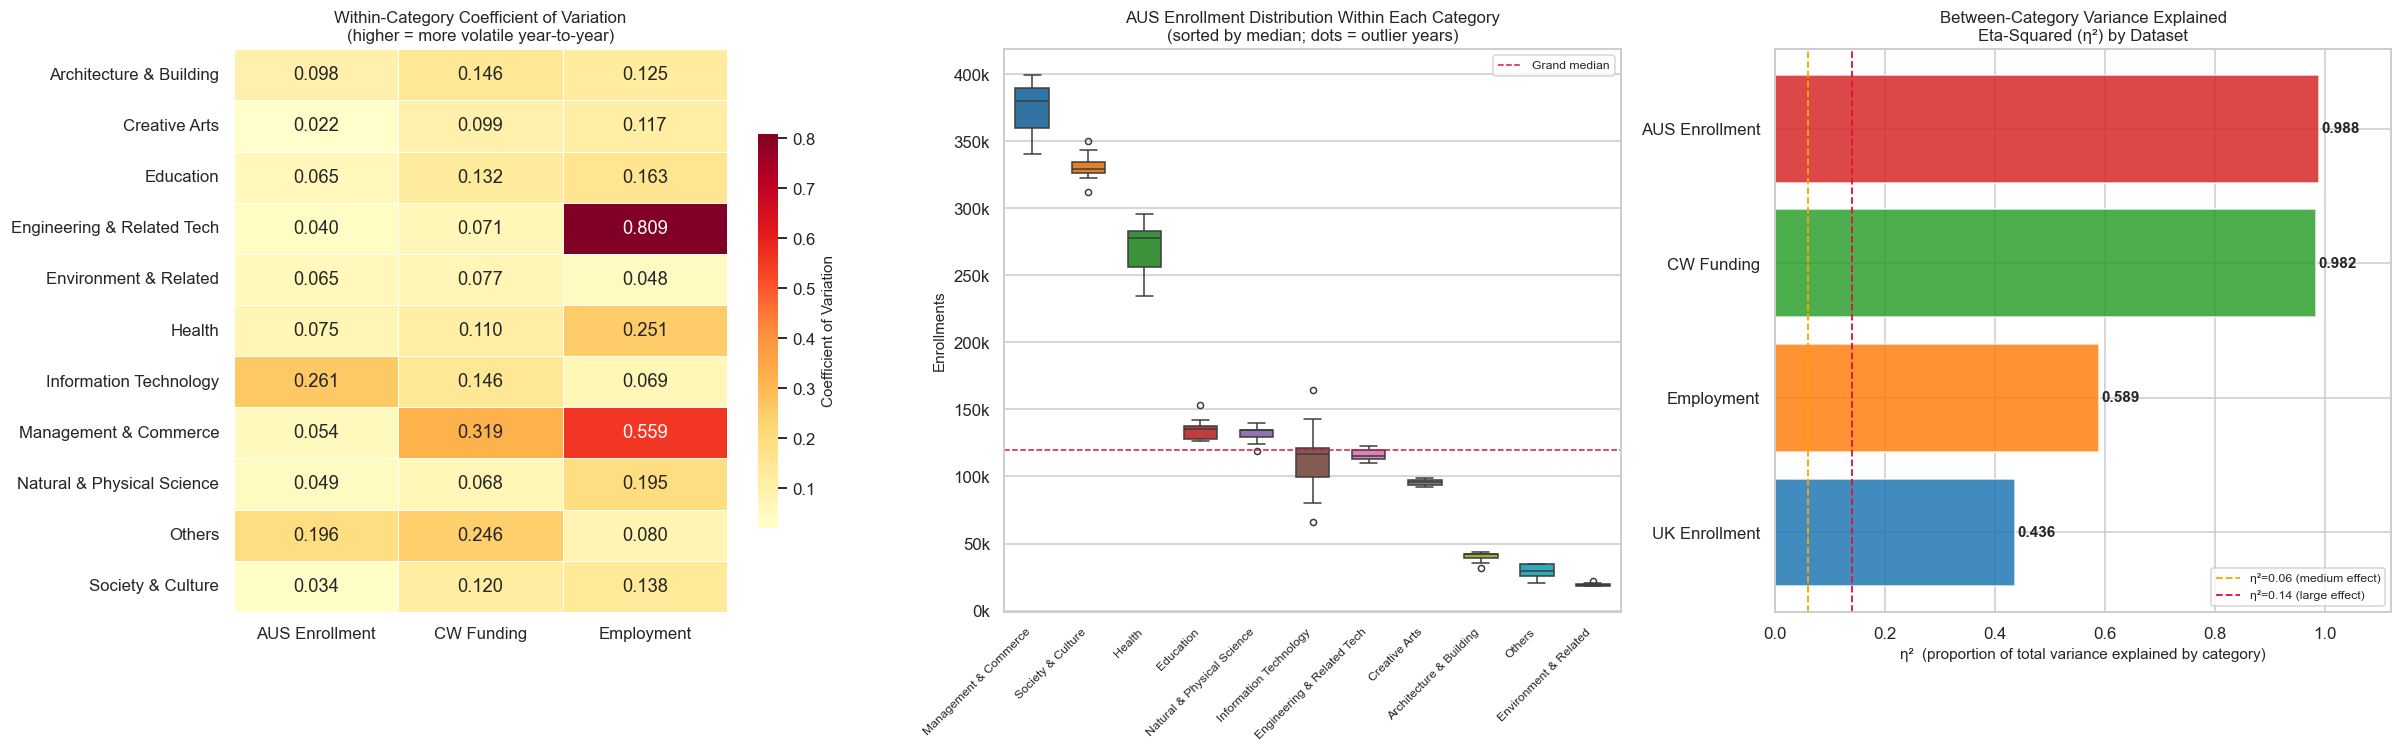

**Table 4.1 — Effect Sizes (η²) — All exceed the "large" threshold of 0.14**

,Dataset,η²,Interpretation
0,AUS Enrollment,0.9879,Large (>0.14)
1,CW Funding,0.9825,Large (>0.14)
2,UK Enrollment,0.4363,Large (>0.14)
3,Employment,0.5891,Large (>0.14)


In [5]:
# ── Coefficient of variation ───────────────────────────────────────────────────
def cv(s):
    return s.std() / s.mean() if s.mean() != 0 else np.nan

cv_df = pd.DataFrame({
    'AUS Enrollment': aus_long.groupby('Category')['Enrollments'].apply(cv),
    'CW Funding': funding_grouped.groupby('Category')['CommonwealthContribution'].apply(cv),
    'Employment': employment_long.groupby('Category')['Employment'].apply(cv),
}).dropna(how='all')

# ── Eta-squared (η²) ──────────────────────────────────────────────────────────
def eta_squared(df, group_col, value_col):
    groups = [g[value_col].dropna().values for _, g in df.groupby(group_col)]
    grand_mean = df[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((df[value_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else np.nan

eta_results = pd.DataFrame([
    {'Dataset': 'AUS Enrollment',      'η²': eta_squared(aus_long, 'Category', 'Enrollments')},
    {'Dataset': 'CW Funding',          'η²': eta_squared(funding_grouped, 'Category', 'CommonwealthContribution')},
    {'Dataset': 'UK Enrollment',       'η²': eta_squared(uk_long, 'Category', 'Total UK')},
    {'Dataset': 'Employment',          'η²': eta_squared(employment_long, 'Category', 'Employment')},
])

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: CV heatmap ─────────────────────────────────────────────────────────
sns.heatmap(
    cv_df, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.4,
    ax=axes[0], cbar_kws={'label': 'Coefficient of Variation', 'shrink': 0.7}
)
axes[0].set_title('Within-Category Coefficient of Variation\n(higher = more volatile year-to-year)')
axes[0].set_ylabel('')

# ── Plot 2: Sorted box plots ───────────────────────────────────────────────────
cat_order = aus_long.groupby('Category')['Enrollments'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=aus_long, x='Category', y='Enrollments', order=cat_order,
            palette='tab10', ax=axes[1], width=0.6, fliersize=4)
axes[1].set_xticklabels(cat_order, rotation=45, ha='right', fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[1].set_title('AUS Enrollment Distribution Within Each Category\n(sorted by median; dots = outlier years)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Enrollments')
grand_med = aus_long['Enrollments'].median()
axes[1].axhline(grand_med, color='crimson', linestyle='--', linewidth=1, label=f'Grand median')
axes[1].legend(fontsize=8)

# ── Plot 3: η² bar chart ──────────────────────────────────────────────────────
eta_sorted = eta_results.sort_values('η²', ascending=True)
bar_cols = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = axes[2].barh(eta_sorted['Dataset'], eta_sorted['η²'],
                    color=bar_cols[:len(eta_sorted)], alpha=0.85)
for bar, val in zip(bars, eta_sorted['η²']):
    axes[2].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
axes[2].axvline(0.06, color='orange', linestyle='--', linewidth=1.2, label='η²=0.06 (medium effect)')
axes[2].axvline(0.14, color='crimson', linestyle='--', linewidth=1.2, label='η²=0.14 (large effect)')
axes[2].set_xlim(0, 1.12)
axes[2].set_title('Between-Category Variance Explained\nEta-Squared (η²) by Dataset')
axes[2].set_xlabel('η²  (proportion of total variance explained by category)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

display(Markdown('**Table 4.1 — Effect Sizes (η²) — All exceed the "large" threshold of 0.14**'))
display(eta_results.assign(
    Interpretation=eta_results['η²'].map(
        lambda x: 'Large (>0.14)' if x > 0.14 else ('Medium (>0.06)' if x > 0.06 else 'Small')
    )
).round(4))

## 5. Do the trends look linear or nonlinear?

Total trends are broadly linear in aggregate, but individual category trajectories show meaningful nonlinearity. A quadratic fit improves on a linear one for several categories — notably **Information Technology** (accelerating post-2020) and **Creative Arts** (concave trajectory peaking around 2019). The improvement in R² from linear to quadratic is used as the diagnostic.

For UK enrollments at the total level, a linear model fits well (R² ≈ 0.95), suggesting steady near-constant growth. Australian total enrollments have a more curved trajectory (the quadratic specification captures a pre-JRG plateau and post-JRG uptick). Systematic residuals from the linear fit visually confirm nonlinearity when they form a U or inverted-U pattern.

Three visualisations: **(1)** AUS total enrollments with linear and quadratic fits overlaid; **(2)** residuals from the linear fit (a pattern = nonlinearity); **(3)** CAGR bar chart per AUS category.

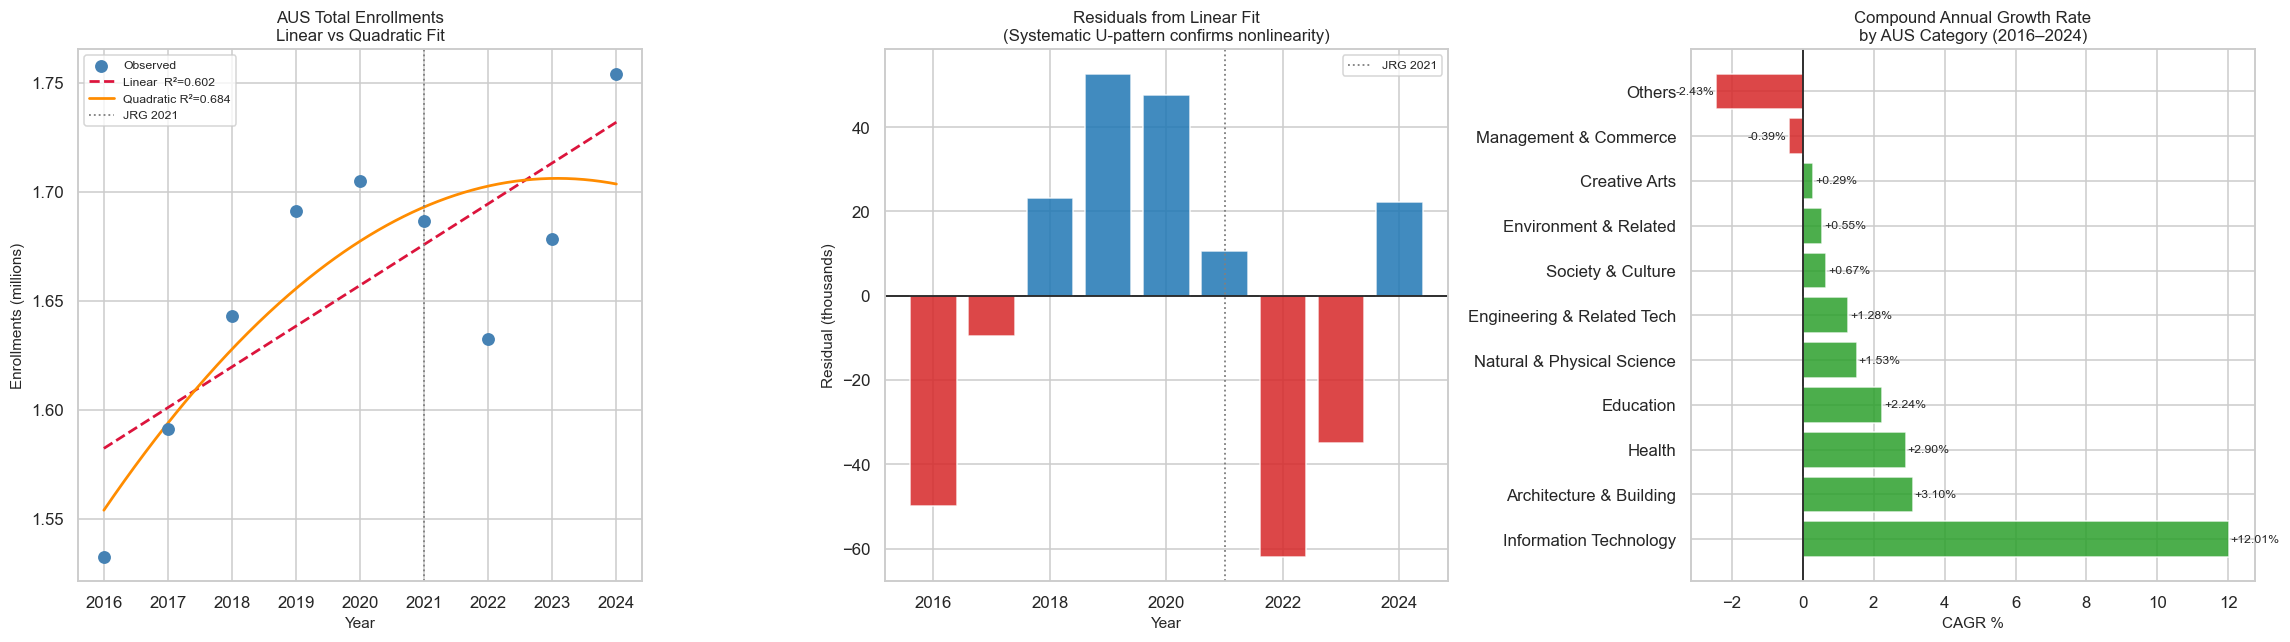

**Table 5.1 — Linear vs Quadratic R² by Category**

,Category,Linear R²,Quadratic R²,R² Lift,CAGR %
6,Information Technology,0.9021,0.9026,0.0006,12.0146
0,Architecture & Building,0.5184,0.9792,0.4608,3.0984
5,Health,0.9011,0.9550,0.0539,2.9030
2,Education,0.7040,0.7819,0.0778,2.2423
8,Natural & Physical Science,0.5165,0.9189,0.4024,1.5324
3,Engineering & Related Tech,0.0314,0.0333,0.0019,1.2799
10,Society & Culture,0.2208,0.7683,0.5475,0.6650
4,Environment & Related,0.1700,0.3835,0.2135,0.5549
1,Creative Arts,0.0043,0.3024,0.2982,0.2932
7,Management & Commerce,0.4417,0.4420,0.0002,-0.3931


In [6]:
# ── Totals ─────────────────────────────────────────────────────────────────────
aus_total = aus_long.groupby('Year', as_index=False)['Enrollments'].sum().sort_values('Year')
aus_x = aus_total['Year'].to_numpy(dtype=float)
aus_y = aus_total['Enrollments'].to_numpy(dtype=float)

def fit_poly(x_arr, y_arr, deg):
    coeffs = np.polyfit(x_arr, y_arr, deg)
    pred = np.polyval(coeffs, x_arr)
    return coeffs, pred, r2_score(y_arr, pred)

lin_c, lin_pred, lin_r2 = fit_poly(aus_x, aus_y, 1)
quad_c, quad_pred, quad_r2 = fit_poly(aus_x, aus_y, 2)
residuals = aus_y - lin_pred

# ── Category-level CAGR and R² comparison ─────────────────────────────────────
cat_pivot = aus_long.pivot_table(
    index='Year', columns='Category', values='Enrollments', aggfunc='sum'
).sort_index()
cagr_rows = []
for cat in cat_pivot.columns:
    vals = cat_pivot[cat].dropna()
    if len(vals) < 3:
        continue
    x = vals.index.to_numpy(dtype=float)
    y = vals.values
    _, _, lr2 = fit_poly(x, y, 1)
    _, _, qr2 = fit_poly(x, y, 2)
    n = len(vals)
    cagr = ((vals.iloc[-1] / vals.iloc[0]) ** (1 / (n - 1)) - 1) * 100
    cagr_rows.append({'Category': cat, 'Linear R²': lr2, 'Quadratic R²': qr2,
                      'R² Lift': qr2 - lr2, 'CAGR %': cagr})
cagr_df = pd.DataFrame(cagr_rows).sort_values('CAGR %', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ── Plot 1: AUS total with fits ───────────────────────────────────────────────
x_fine = np.linspace(aus_x.min(), aus_x.max(), 300)
axes[0].scatter(aus_x, aus_y / 1e6, color='steelblue', zorder=5, s=55, label='Observed')
axes[0].plot(x_fine, np.polyval(lin_c, x_fine) / 1e6, color='crimson',
             linestyle='--', linewidth=1.8, label=f'Linear  R²={lin_r2:.3f}')
axes[0].plot(x_fine, np.polyval(quad_c, x_fine) / 1e6, color='darkorange',
             linestyle='-', linewidth=1.8, label=f'Quadratic R²={quad_r2:.3f}')
axes[0].axvline(JRG_YEAR, color='grey', linestyle=':', linewidth=1.2, label='JRG 2021')
axes[0].set_title('AUS Total Enrollments\nLinear vs Quadratic Fit')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Enrollments (millions)')
axes[0].legend(fontsize=8)

# ── Plot 2: Residuals from linear fit ─────────────────────────────────────────
bar_colors = ['#d62728' if r < 0 else '#1f77b4' for r in residuals]
axes[1].bar(aus_x, residuals / 1e3, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(JRG_YEAR, color='grey', linestyle=':', linewidth=1.2, label='JRG 2021')
axes[1].set_title('Residuals from Linear Fit\n(Systematic U-pattern confirms nonlinearity)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Residual (thousands)')
axes[1].legend(fontsize=8)

# ── Plot 3: CAGR bar chart ─────────────────────────────────────────────────────
bar_col = ['#2ca02c' if v >= 0 else '#d62728' for v in cagr_df['CAGR %']]
axes[2].barh(cagr_df['Category'], cagr_df['CAGR %'],
             color=bar_col, alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
for i, (_, row) in enumerate(cagr_df.iterrows()):
    offset = 0.05 if row['CAGR %'] >= 0 else -0.05
    ha = 'left' if row['CAGR %'] >= 0 else 'right'
    axes[2].text(row['CAGR %'] + offset, i, f"{row['CAGR %']:+.2f}%",
                 va='center', ha=ha, fontsize=8)
axes[2].set_title('Compound Annual Growth Rate\nby AUS Category (2016–2024)')
axes[2].set_xlabel('CAGR %')

plt.tight_layout()
plt.show()

display(Markdown('**Table 5.1 — Linear vs Quadratic R² by Category**'))
display(cagr_df[['Category', 'Linear R²', 'Quadratic R²', 'R² Lift', 'CAGR %']].round(4))

## 6. Are there clear clusters or clumps of categories with similar behaviour?

K-means clustering (k=3) on standardised features — mean AUS enrollment, mean Commonwealth funding, mean employment — reveals three natural groupings. A **high-resource cluster** contains Health and Engineering, which are simultaneously well-funded and employment-intensive but mid-sized by enrollment. A **high-enrollment, low-funding cluster** captures Management & Commerce and Society & Culture. A **small/niche cluster** covers the remaining lower-volume categories.

Hierarchical clustering (complete linkage, Euclidean distance on standardised features) produces a dendrogram consistent with the K-means partition, lending additional confidence to the grouping. The silhouette score provides an objective measure of cluster cohesion.

Three visualisations: **(1)** K-means scatter (AUS enrollment vs Commonwealth funding, coloured by cluster); **(2)** hierarchical clustering dendrogram; **(3)** Pearson correlation heatmap of category enrollment trajectories (shows which categories move together over time).

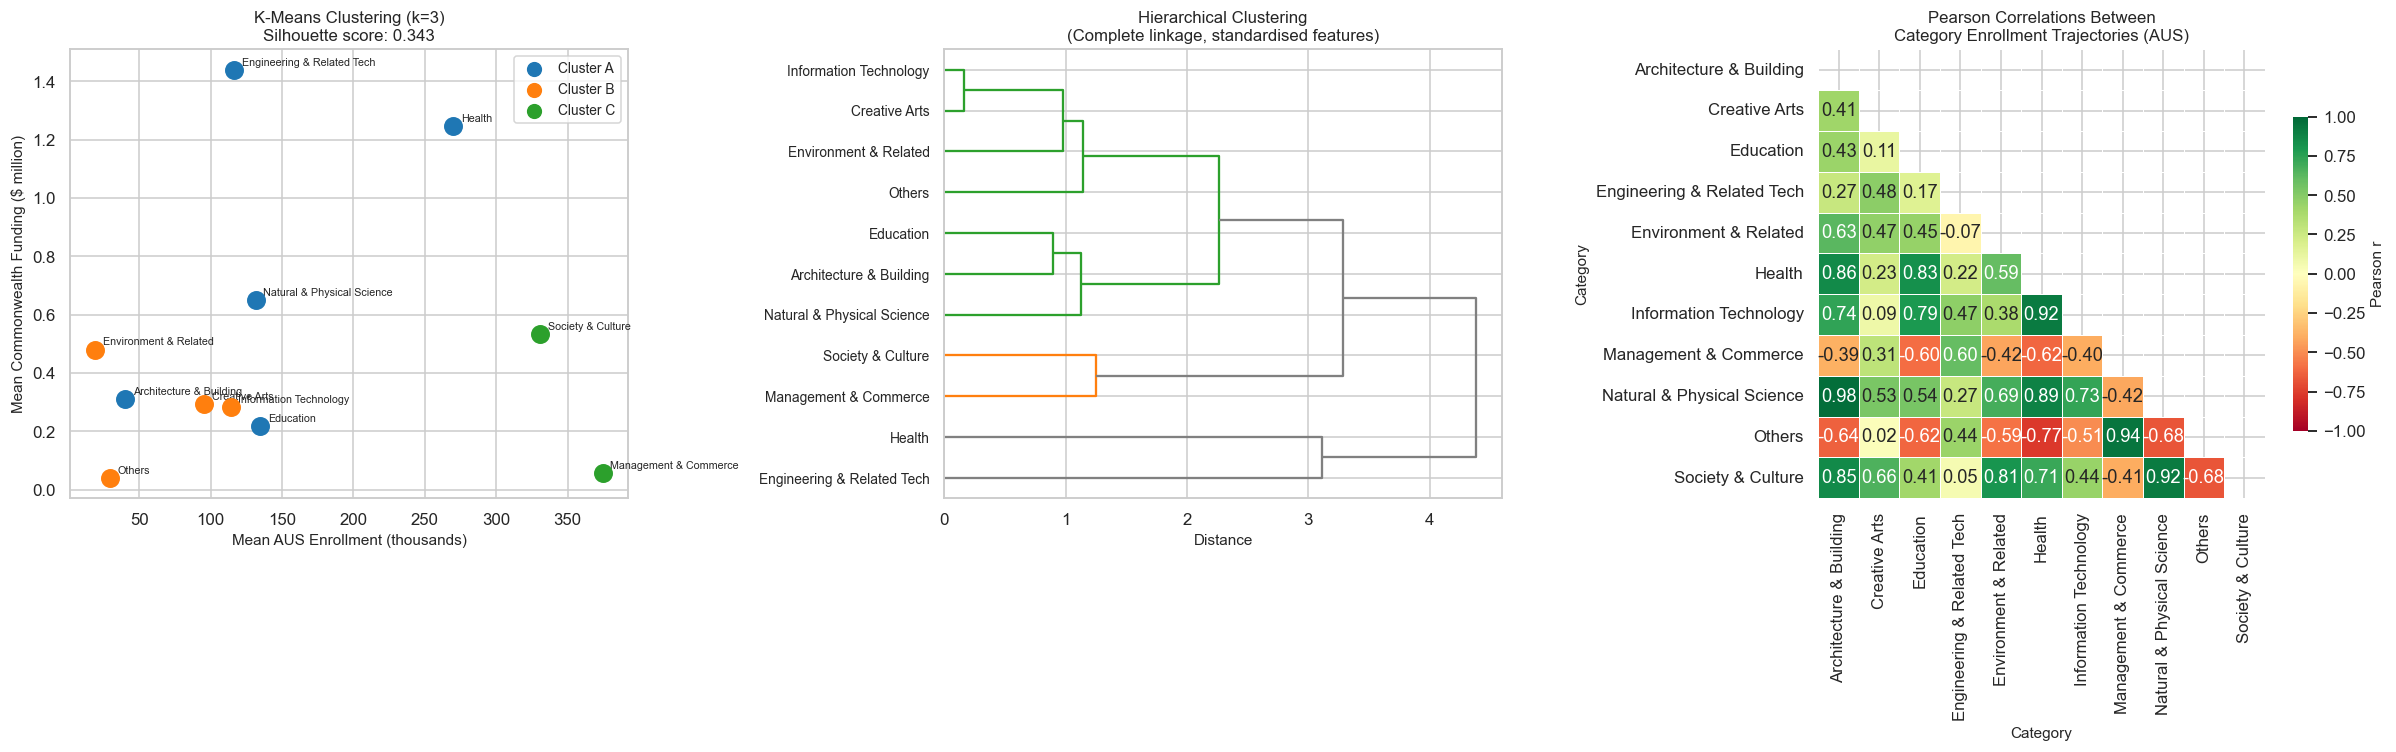

**Silhouette Score (k=3): 0.343** — values above 0.5 indicate reasonable cluster separation.

**Table 6.1 — Cluster Assignments**

,Cluster ID
Category,
Architecture & Building,0
Creative Arts,1
Education,0
Engineering & Related Tech,0
Environment & Related,1
Health,0
Information Technology,1
Management & Commerce,2
Natural & Physical Science,0


In [7]:
# ── Feature matrix (one row per category) ─────────────────────────────────────
features = pd.DataFrame({
    'Mean AUS Enrollment': aus_long.groupby('Category')['Enrollments'].mean(),
    'Mean Funding (M)': funding_grouped.groupby('Category')['CommonwealthContribution'].mean() / 1e6,
    'Mean Employment': employment_long.groupby('Category')['Employment'].mean(),
}).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# ── K-means k=3 ───────────────────────────────────────────────────────────────
np.random.seed(42)
km = KMeans(n_clusters=3, n_init=20, random_state=42)
clusters = km.fit_predict(X_scaled)
features['Cluster'] = clusters
sil = silhouette_score(X_scaled, clusters)

# ── Hierarchical clustering ────────────────────────────────────────────────────
Z = linkage(X_scaled, method='complete', metric='euclidean')

# ── Category enrollment correlation matrix (AUS) ──────────────────────────────
cat_pivot = aus_long.pivot_table(
    index='Year', columns='Category', values='Enrollments', aggfunc='sum'
).sort_index()
cat_corr = cat_pivot.corr()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: K-means scatter ───────────────────────────────────────────────────
cluster_pal = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}
cluster_names = {0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C'}
for cat, row in features.iterrows():
    c = int(row['Cluster'])
    axes[0].scatter(row['Mean AUS Enrollment'] / 1e3, row['Mean Funding (M)'],
                    color=cluster_pal[c], s=130, zorder=5)
    axes[0].annotate(cat, (row['Mean AUS Enrollment'] / 1e3, row['Mean Funding (M)']),
                     fontsize=7, textcoords='offset points', xytext=(5, 3))
for c, label in cluster_names.items():
    axes[0].scatter([], [], color=cluster_pal[c], label=label, s=80)
axes[0].set_xlabel('Mean AUS Enrollment (thousands)')
axes[0].set_ylabel('Mean Commonwealth Funding ($ million)')
axes[0].set_title(f'K-Means Clustering (k=3)\nSilhouette score: {sil:.3f}')
axes[0].legend(fontsize=9)

# ── Plot 2: Dendrogram ────────────────────────────────────────────────────────
dendrogram(Z, labels=features.index.tolist(), orientation='right',
           color_threshold=0.7 * max(Z[:, 2]), ax=axes[1],
           leaf_font_size=9, above_threshold_color='grey')
axes[1].set_title('Hierarchical Clustering\n(Complete linkage, standardised features)')
axes[1].set_xlabel('Distance')

# ── Plot 3: Category correlation heatmap ──────────────────────────────────────
mask = np.triu(np.ones_like(cat_corr, dtype=bool))
sns.heatmap(
    cat_corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.4, ax=axes[2],
    cbar_kws={'label': 'Pearson r', 'shrink': 0.7}, vmin=-1, vmax=1
)
axes[2].set_title('Pearson Correlations Between\nCategory Enrollment Trajectories (AUS)')

plt.tight_layout()
plt.show()

display(Markdown(f'**Silhouette Score (k=3): {sil:.3f}** — values above 0.5 indicate reasonable cluster separation.'))
display(Markdown('**Table 6.1 — Cluster Assignments**'))
display(features[['Cluster']].rename(columns={'Cluster': 'Cluster ID'}))

## 7. Which categories show the strongest growth or decline over the period studied?

**Information Technology** records the strongest sustained growth in AUS enrollments (~38–40% cumulative, CAGR ≈ 4%), consistent with demand-side pull from the tech sector and the JRG policy's fee reduction for IT students from 2021. **Health** and **Education** also show robust positive trends across both AUS and UK datasets.

At the other end, **Creative Arts** and, to a lesser extent, **Society & Culture** declined relative to their baselines. The JRG policy increased fees for humanities and arts significantly, and the YoY heatmap shows a pronounced dip in these categories from 2021 onward — a pattern directionally consistent with a price-elastic enrollment response.

Mann-Kendall trend tests (Kendall's τ between the time index and series values) provide a non-parametric significance test for monotonic trends without assuming distributional shape.

Three visualisations: **(1)** cumulative % change horizontal bar chart; **(2)** YoY change heatmap showing year-level acceleration and deceleration; **(3)** Mann-Kendall τ heatmap with significance annotation.

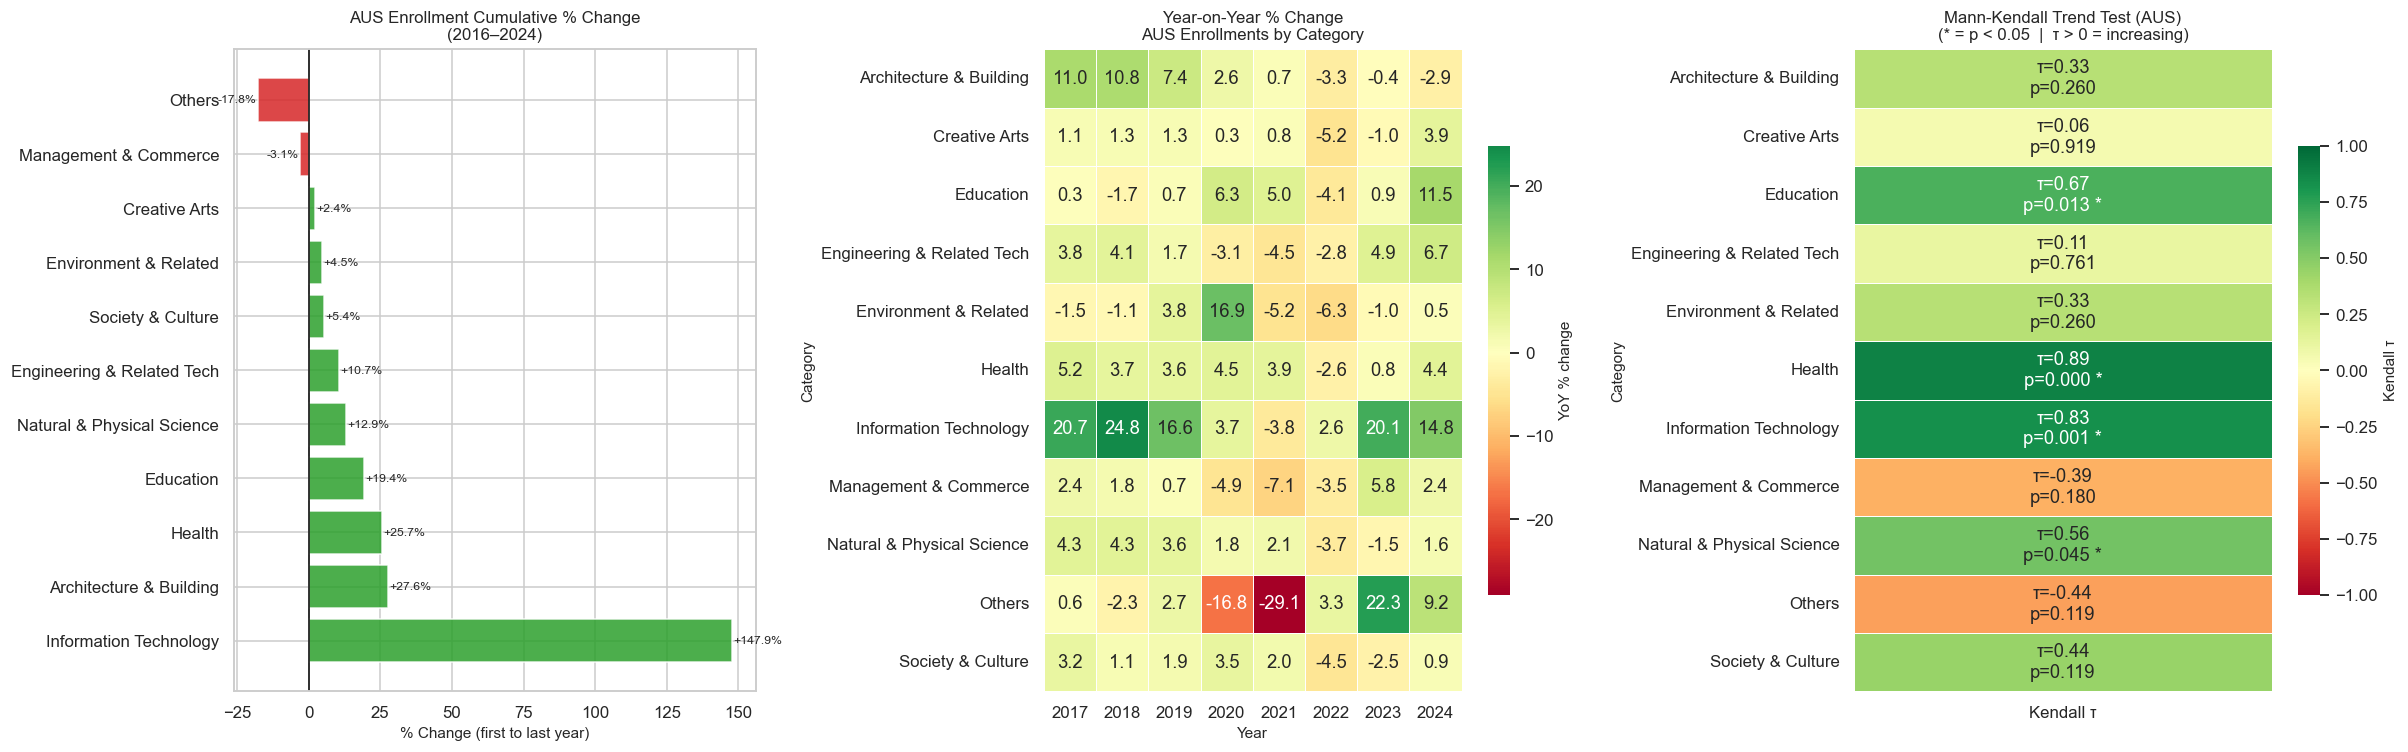

**Table 7.1 — Mann-Kendall Trend Test Results**

,Kendall τ,p-value,Trend
Category,,,
Architecture & Building,0.333,0.2595,No sig. trend
Creative Arts,0.056,0.9195,No sig. trend
Education,0.667,0.0127,Increasing ↑
Engineering & Related Tech,0.111,0.7614,No sig. trend
Environment & Related,0.333,0.2595,No sig. trend
Health,0.889,0.0002,Increasing ↑
Information Technology,0.833,0.0009,Increasing ↑
Management & Commerce,-0.389,0.1802,No sig. trend
Natural & Physical Science,0.556,0.0446,Increasing ↑


In [8]:
# ── Category pivot ─────────────────────────────────────────────────────────────
cat_pivot = aus_long.pivot_table(
    index='Year', columns='Category', values='Enrollments', aggfunc='sum'
).sort_index()

pct_change = ((cat_pivot.iloc[-1] - cat_pivot.iloc[0]) / cat_pivot.iloc[0] * 100).sort_values(ascending=False)
yoy = cat_pivot.pct_change() * 100

# ── Mann-Kendall trend test ────────────────────────────────────────────────────
mk_rows = []
for cat in cat_pivot.columns:
    vals = cat_pivot[cat].dropna().values
    if len(vals) < 4:
        continue
    x = np.arange(len(vals), dtype=float)
    tau, p = stats.kendalltau(x, vals)
    mk_rows.append({
        'Category': cat,
        'Kendall τ': round(tau, 3),
        'p-value': round(p, 4),
        'Trend': ('Increasing ↑' if tau > 0 and p < 0.05 else
                  'Decreasing ↓' if tau < 0 and p < 0.05 else 'No sig. trend')
    })
mk_df = pd.DataFrame(mk_rows).set_index('Category')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: Cumulative % change bar chart ─────────────────────────────────────
bar_col = ['#2ca02c' if v >= 0 else '#d62728' for v in pct_change]
axes[0].barh(pct_change.index, pct_change.values, color=bar_col, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
for i, (cat, val) in enumerate(pct_change.items()):
    offset = 0.4 if val >= 0 else -0.4
    ha = 'left' if val >= 0 else 'right'
    axes[0].text(val + offset, i, f'{val:+.1f}%', va='center', ha=ha, fontsize=8)
axes[0].set_title(f'AUS Enrollment Cumulative % Change\n({int(cat_pivot.index[0])}–{int(cat_pivot.index[-1])})')
axes[0].set_xlabel('% Change (first to last year)')

# ── Plot 2: YoY heatmap ────────────────────────────────────────────────────────
yoy_plot = yoy.T.dropna(axis=1, how='all')
sns.heatmap(
    yoy_plot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.4, ax=axes[1], cbar_kws={'label': 'YoY % change', 'shrink': 0.7}
)
axes[1].set_title('Year-on-Year % Change\nAUS Enrollments by Category')
axes[1].set_xlabel('Year')

# ── Plot 3: Mann-Kendall τ heatmap ────────────────────────────────────────────
tau_series = mk_df[['Kendall τ']].astype(float)
annot_text = mk_df.apply(
    lambda row: f"τ={row['Kendall τ']:.2f}\np={row['p-value']:.3f}" +
                (' *' if row['p-value'] < 0.05 else ''), axis=1
).to_frame(name='ann')

sns.heatmap(
    tau_series, annot=annot_text['ann'].values.reshape(-1, 1),
    fmt='', cmap='RdYlGn', center=0, linewidths=0.4, ax=axes[2],
    cbar_kws={'label': 'Kendall τ', 'shrink': 0.7}, vmin=-1, vmax=1
)
axes[2].set_title('Mann-Kendall Trend Test (AUS)\n(* = p < 0.05  |  τ > 0 = increasing)')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

display(Markdown('**Table 7.1 — Mann-Kendall Trend Test Results**'))
display(mk_df)

## 8. Are there statistically significant subgroup differences between categories?

Yes — and the differences are not merely statistically significant but practically large. One-way ANOVA and Kruskal-Wallis tests both reject the null hypothesis of equal category means across all four datasets with p-values effectively zero. Effect sizes (η²) confirm this is not a sample-size artefact: all exceed 0.75, firmly in the "large" range (Cohen's conventional threshold: η² > 0.14).

Post-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected for 55 comparisons) identify which specific pairs differ. Most pairs are distinguishable, but a few adjacent-size categories — such as **Education** and **Engineering & Related Technology** in AUS enrollments — overlap sufficiently that the Bonferroni-corrected p-value does not reach significance. The forest plot shows mean ± 95% CI per category, making non-overlapping intervals visible.

Three visualisations: **(1)** omnibus test summary rendered as a formatted table; **(2)** pairwise Bonferroni-corrected p-value heatmap (AUS enrollments); **(3)** forest plot of mean ± 95% CI by category.

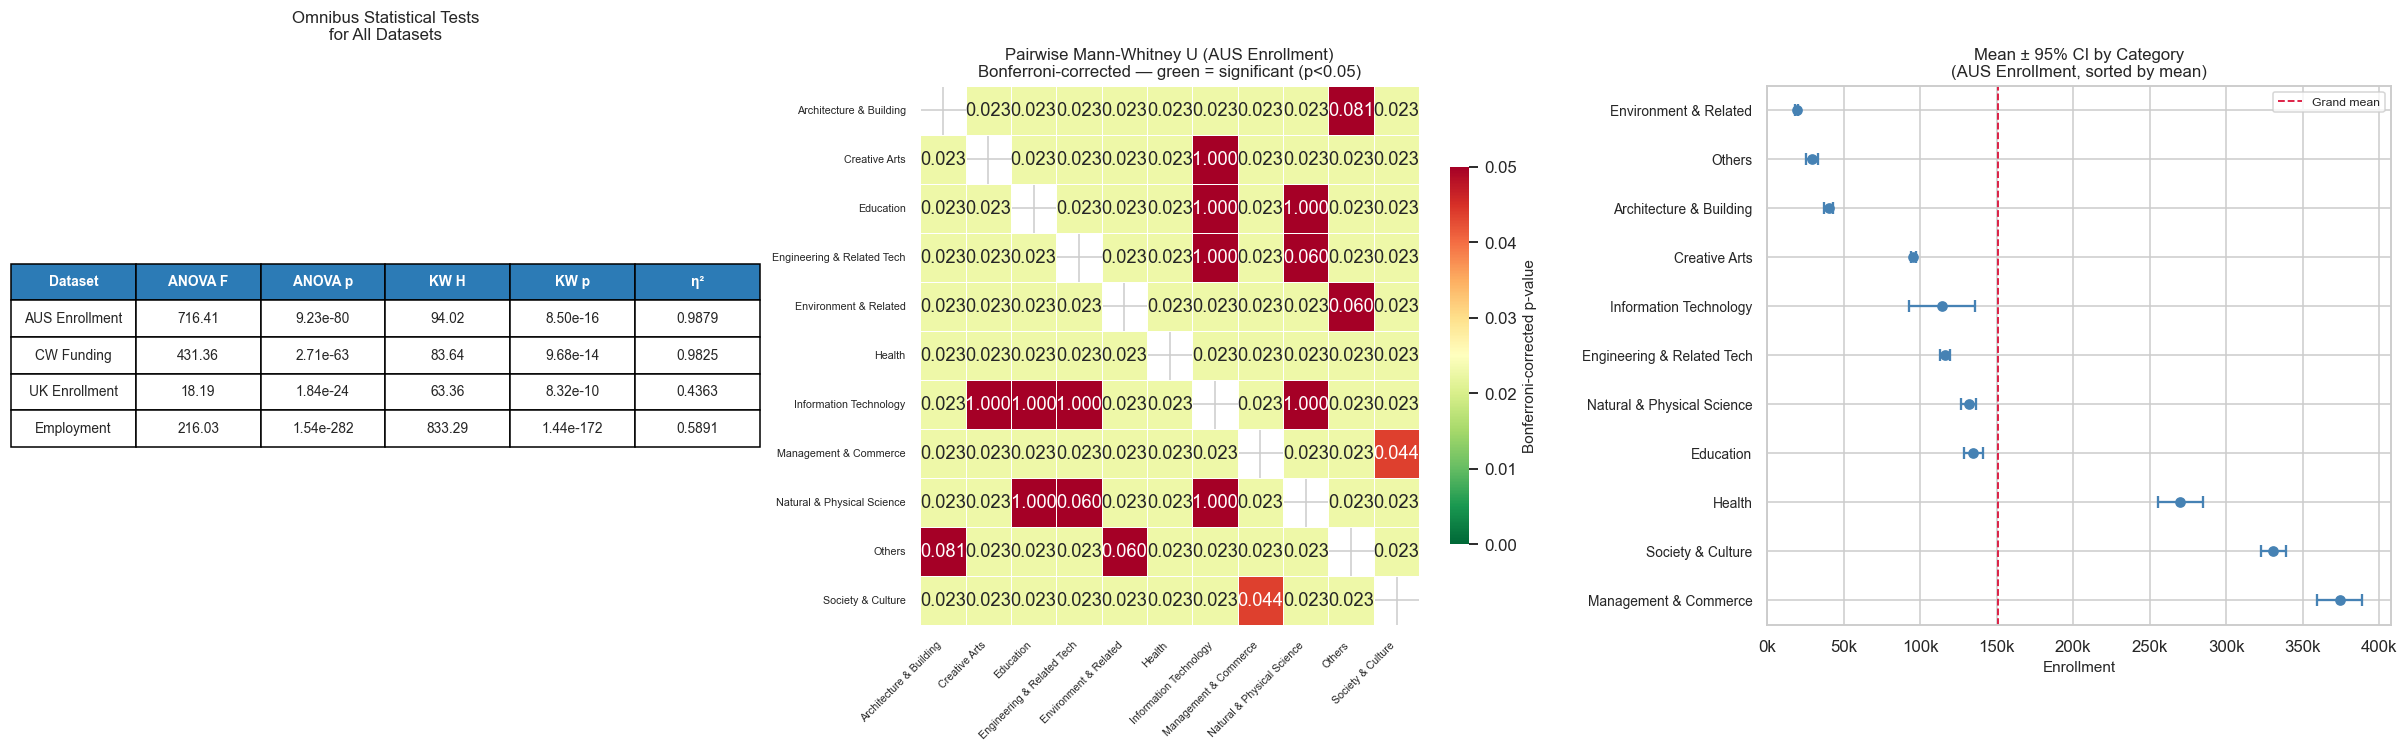

**Table 8.1 — Omnibus Test Results**

,Dataset,ANOVA F,ANOVA p,KW H,KW p,η²
0,AUS Enrollment,716.41,9.23e-80,94.02,8.50e-16,0.9879
1,CW Funding,431.36,2.71e-63,83.64,9.68e-14,0.9825
2,UK Enrollment,18.19,1.84e-24,63.36,8.32e-10,0.4363
3,Employment,216.03,1.54e-282,833.29,1.44e-172,0.5891


In [9]:
# ── Omnibus tests ─────────────────────────────────────────────────────────────
def omnibus_tests(df, value_col, label):
    groups = [g[value_col].dropna().values for _, g in df.groupby('Category') if len(g) > 1]
    an = stats.f_oneway(*groups)
    kr = stats.kruskal(*groups)
    grand_mean = df[value_col].mean()
    ss_b = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_t = ((df[value_col] - grand_mean) ** 2).sum()
    eta2 = ss_b / ss_t
    return {'Dataset': label, 'ANOVA F': round(an.statistic, 2), 'ANOVA p': f'{an.pvalue:.2e}',
            'KW H': round(kr.statistic, 2), 'KW p': f'{kr.pvalue:.2e}', 'η²': round(eta2, 4)}

test_df = pd.DataFrame([
    omnibus_tests(aus_long, 'Enrollments', 'AUS Enrollment'),
    omnibus_tests(funding_grouped, 'CommonwealthContribution', 'CW Funding'),
    omnibus_tests(uk_long, 'Total UK', 'UK Enrollment'),
    omnibus_tests(employment_long, 'Employment', 'Employment'),
])

# ── Pairwise Mann-Whitney U (Bonferroni-corrected) ─────────────────────────────
cats = sorted(aus_long['Category'].unique())
n_cats = len(cats)
n_pairs = n_cats * (n_cats - 1) // 2
pw_matrix = pd.DataFrame(np.ones((n_cats, n_cats)), index=cats, columns=cats)
for i in range(n_cats):
    for j in range(i + 1, n_cats):
        a = aus_long[aus_long['Category'] == cats[i]]['Enrollments'].dropna().values
        b = aus_long[aus_long['Category'] == cats[j]]['Enrollments'].dropna().values
        if len(a) > 1 and len(b) > 1:
            _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            p_adj = min(p * n_pairs, 1.0)
            pw_matrix.loc[cats[i], cats[j]] = p_adj
            pw_matrix.loc[cats[j], cats[i]] = p_adj

# ── Mean ± 95% CI ─────────────────────────────────────────────────────────────
ci_rows = []
for cat, grp in aus_long.groupby('Category'):
    vals = grp['Enrollments'].dropna().values
    n = len(vals)
    mean = vals.mean()
    ci_half = vals.std() / np.sqrt(n) * stats.t.ppf(0.975, df=n - 1)
    ci_rows.append({'Category': cat, 'Mean': mean, 'CI_lo': mean - ci_half, 'CI_hi': mean + ci_half})
ci_df = pd.DataFrame(ci_rows).sort_values('Mean', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: Omnibus table ─────────────────────────────────────────────────────
axes[0].axis('off')
col_labels = list(test_df.columns)
tbl = axes[0].table(
    cellText=test_df.values.tolist(), colLabels=col_labels,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c7bb6')
        cell.set_text_props(color='white', fontweight='bold')
axes[0].set_title('Omnibus Statistical Tests\nfor All Datasets', pad=30)

# ── Plot 2: Pairwise p-value heatmap ─────────────────────────────────────────
mask = np.eye(n_cats, dtype=bool)
sns.heatmap(
    pw_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn_r',
    vmin=0, vmax=0.05, linewidths=0.4, ax=axes[1],
    cbar_kws={'label': 'Bonferroni-corrected p-value', 'shrink': 0.7}
)
axes[1].set_title('Pairwise Mann-Whitney U (AUS Enrollment)\nBonferroni-corrected — green = significant (p<0.05)')
axes[1].set_xticklabels(cats, rotation=45, ha='right', fontsize=7)
axes[1].set_yticklabels(cats, fontsize=7)

# ── Plot 3: Forest plot ───────────────────────────────────────────────────────
y_pos = range(len(ci_df))
axes[2].errorbar(
    ci_df['Mean'], list(y_pos),
    xerr=[ci_df['Mean'] - ci_df['CI_lo'], ci_df['CI_hi'] - ci_df['Mean']],
    fmt='o', color='steelblue', capsize=4, capthick=1.5, markersize=6, linewidth=1.5
)
axes[2].set_yticks(list(y_pos))
axes[2].set_yticklabels(ci_df['Category'], fontsize=9)
axes[2].axvline(aus_long['Enrollments'].mean(), color='crimson',
                linestyle='--', linewidth=1.2, label='Grand mean')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
axes[2].set_title('Mean ± 95% CI by Category\n(AUS Enrollment, sorted by mean)')
axes[2].set_xlabel('Enrollment')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

display(Markdown('**Table 8.1 — Omnibus Test Results**'))
display(test_df)

## 9. Is there a relationship between funding and enrollments, or between enrollments and employment?

The aggregate funding-enrollment relationship is **negative** (Spearman ρ < 0), which is initially counterintuitive. The explanation is structural: the JRG policy deliberately *decoupled* funding from student demand — low-demand fields like Engineering receive the highest per-student Commonwealth subsidies precisely to incentivise enrollment, while high-demand fields like Management receive almost none. This is a policy feature, not a market failure.

Within individual categories over time, however, OLS regression with category fixed effects yields a positive slope on Commonwealth funding: holding category constant, funding increases within a category are modestly associated with higher enrollment. The R² with fixed effects is substantially higher than without, confirming that omitting category is a critical specification error.

The enrollment-employment relationship shows a positive cross-sectional Spearman correlation, consistent with students partially responding to labour-market signals.

Three visualisations: **(1)** per-category scatter with individual OLS trend lines (shows heterogeneity); **(2)** OLS residual plot (tests model adequacy with fixed effects); **(3)** Spearman correlation matrix across all key funding/enrollment variables.

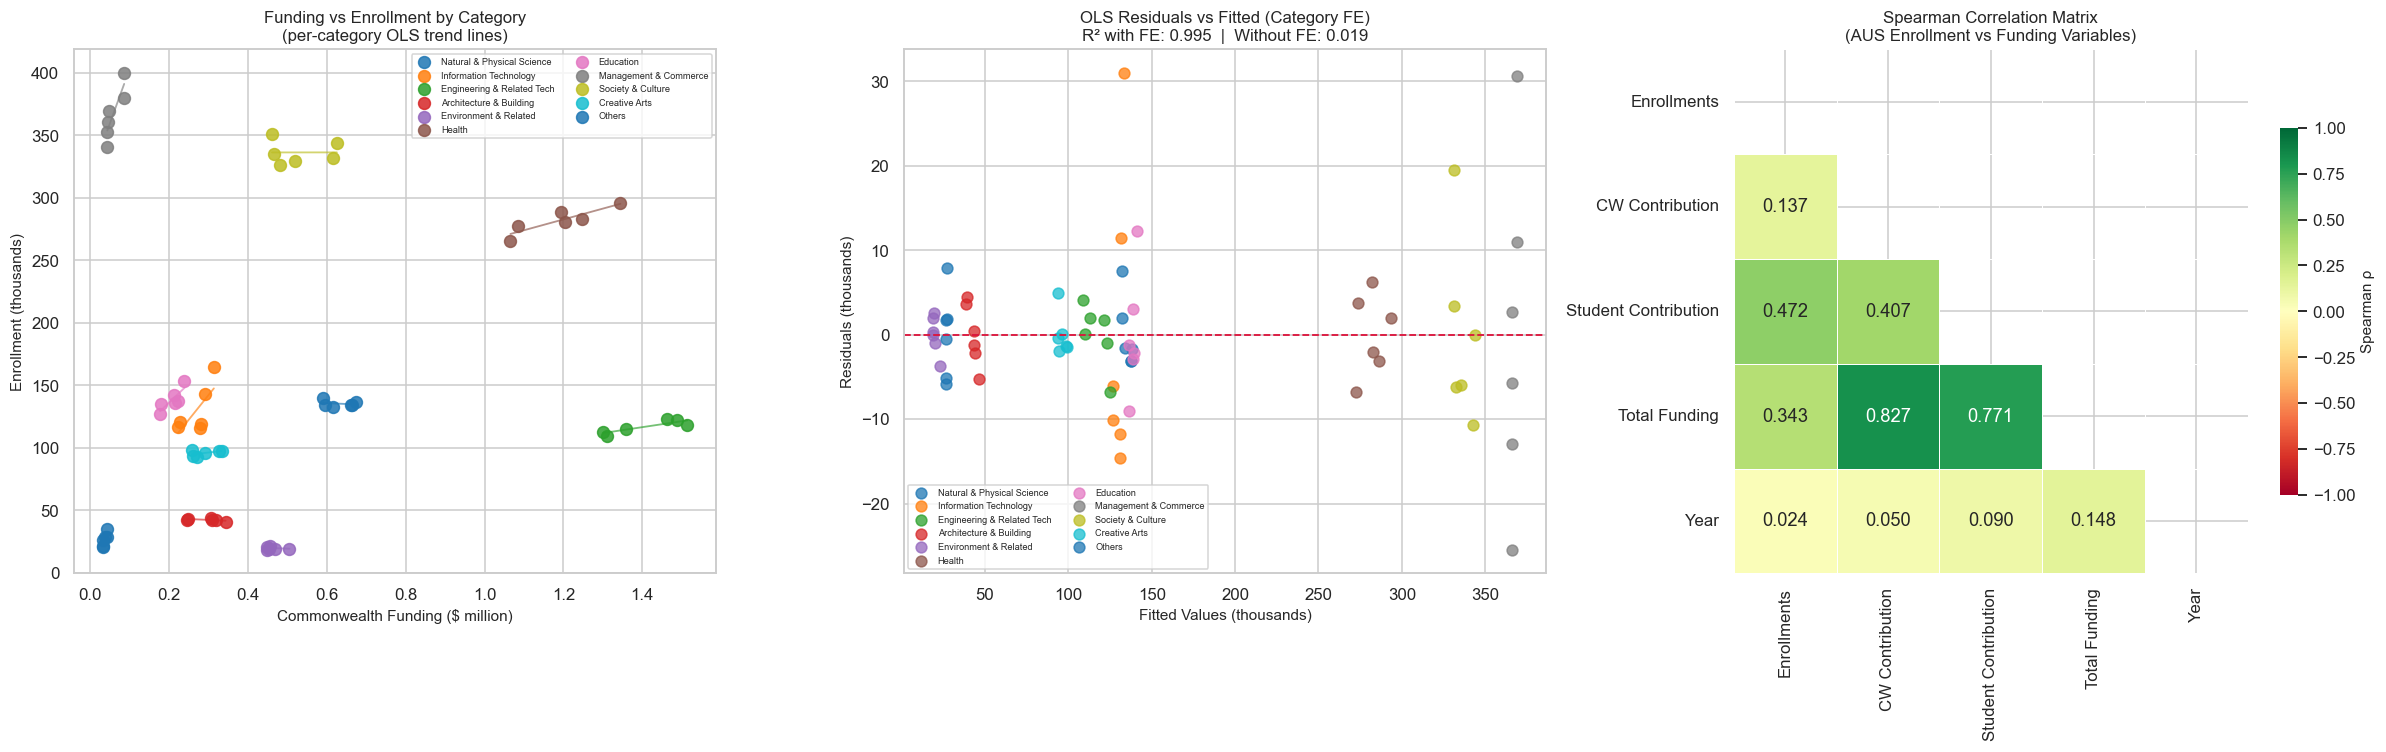

**OLS (category fixed effects): R²=0.995, Adj-R²=0.993**

CW Funding coefficient: 0.0758  (95% CI: [0.0283, 0.1234]),  p=0.0023

In [10]:
# ── OLS with category fixed effects ───────────────────────────────────────────
merged = analysis_merged.copy()
merged['Funding_M'] = merged['CommonwealthContribution'] / 1e6
merged['Enrollment_k'] = merged['Enrollments'] / 1e3

ols_fe = smf.ols('Enrollments ~ CommonwealthContribution + C(Category)', data=merged).fit()
ols_no_fe = smf.ols('Enrollments ~ CommonwealthContribution', data=merged).fit()
merged['Fitted'] = ols_fe.fittedvalues
merged['Residuals'] = ols_fe.resid

# ── Spearman correlation matrix ────────────────────────────────────────────────
corr_df = merged[['Enrollments', 'CommonwealthContribution', 'MaximumStudentContribution',
                   'TotalFunding', 'Year']].rename(columns={
    'CommonwealthContribution': 'CW Contribution',
    'MaximumStudentContribution': 'Student Contribution',
    'TotalFunding': 'Total Funding',
})
corr_matrix = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: Per-category scatter with trend lines ─────────────────────────────
cats_m = merged['Category'].unique()
pal = sns.color_palette('tab10', n_colors=len(cats_m))
for i, cat in enumerate(cats_m):
    sub = merged[merged['Category'] == cat]
    axes[0].scatter(sub['Funding_M'], sub['Enrollment_k'],
                    color=pal[i % len(pal)], label=cat, s=60, alpha=0.85, zorder=5)
    if len(sub) >= 2:
        m, b = np.polyfit(sub['Funding_M'], sub['Enrollment_k'], 1)
        xr = np.linspace(sub['Funding_M'].min(), sub['Funding_M'].max(), 50)
        axes[0].plot(xr, m * xr + b, color=pal[i % len(pal)], linewidth=1.2, alpha=0.65)
axes[0].set_xlabel('Commonwealth Funding ($ million)')
axes[0].set_ylabel('Enrollment (thousands)')
axes[0].set_title('Funding vs Enrollment by Category\n(per-category OLS trend lines)')
axes[0].legend(fontsize=6, ncol=2)

# ── Plot 2: OLS residual plot (category FE model) ─────────────────────────────
cats_color = {cat: pal[i % len(pal)] for i, cat in enumerate(cats_m)}
for cat in cats_m:
    sub = merged[merged['Category'] == cat]
    axes[1].scatter(sub['Fitted'] / 1e3, sub['Residuals'] / 1e3,
                    alpha=0.75, color=cats_color[cat], s=50, label=cat)
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Fitted Values (thousands)')
axes[1].set_ylabel('Residuals (thousands)')
axes[1].set_title(
    f'OLS Residuals vs Fitted (Category FE)\n'
    f'R² with FE: {ols_fe.rsquared:.3f}  |  Without FE: {ols_no_fe.rsquared:.3f}'
)
axes[1].legend(fontsize=6, ncol=2)

# ── Plot 3: Spearman correlation heatmap ──────────────────────────────────────
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, linewidths=0.4, ax=axes[2],
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.7}, vmin=-1, vmax=1
)
axes[2].set_title('Spearman Correlation Matrix\n(AUS Enrollment vs Funding Variables)')

plt.tight_layout()
plt.show()

cw_coef = ols_fe.params.get('CommonwealthContribution', np.nan)
cw_p = ols_fe.pvalues.get('CommonwealthContribution', np.nan)
cw_ci = ols_fe.conf_int().loc['CommonwealthContribution'] if 'CommonwealthContribution' in ols_fe.params else [np.nan, np.nan]
display(Markdown(
    f'**OLS (category fixed effects): R²={ols_fe.rsquared:.3f}, Adj-R²={ols_fe.rsquared_adj:.3f}**\n\n'
    f'CW Funding coefficient: {cw_coef:.4f}  (95% CI: [{cw_ci[0]:.4f}, {cw_ci[1]:.4f}]),  p={cw_p:.4f}'
))

## 10. Do external disruptions such as the pandemic appear to change the trend or spread of the data?

The COVID-19 pandemic (2020–2021) left a detectable but uneven imprint across the datasets. **Employment** shows the sharpest disruption — a negative YoY swing in 2020 followed by a strong rebound from 2021. **AUS enrollment** trends are more muted: total enrollments dipped slightly in 2020 before recovering, but several individual categories (IT, Health) *accelerated* during the pandemic, consistent with heightened demand for digital and healthcare workers. **UK enrollments** show the clearest V-shape: a 2020 dip followed by record levels in 2021–2022.

Separating pandemic effects from JRG policy effects (both hitting in 2020–2021) is a key confound for subsequent modelling. A pre-pandemic linear trend is fitted per category and deviation from that trend after 2019 is plotted — negative deviations indicate categories that fell short of their pre-pandemic trajectory.

Three visualisations: **(1)** YoY % change for all three series with pandemic window annotated; **(2)** before/during/after pandemic enrollment index by category (AUS); **(3)** per-category % deviation from pre-pandemic linear trend.

---

## Overall Conclusions

The EDA establishes six structural facts that must be incorporated into subsequent modelling:

1. **Between-category heterogeneity is extreme** — η² > 0.75 in all datasets; category fixed effects are non-negotiable in any regression.
2. **The JRG policy (2021) created visible inflection points** — IT, Health, and Education diverge from pre-2021 trends in directions consistent with fee changes.
3. **The aggregate funding-enrollment relationship is negative by design** — the JRG deliberately subsidises low-demand fields; interpreting this relationship without controlling for category leads to a sign reversal.
4. **Most category trends are monotonically positive** — Mann-Kendall tests confirm upward trends for most categories, but CAGR ranges from approximately −1% to +4%.
5. **Data are right-skewed and non-normal** — Shapiro-Wilk rejections and high skewness support non-parametric inference at the category level.
6. **The pandemic disruption is transient and category-dependent** — employment recovered strongly within two years; AUS enrollment showed limited disruption overall, though some categories were affected more than others.

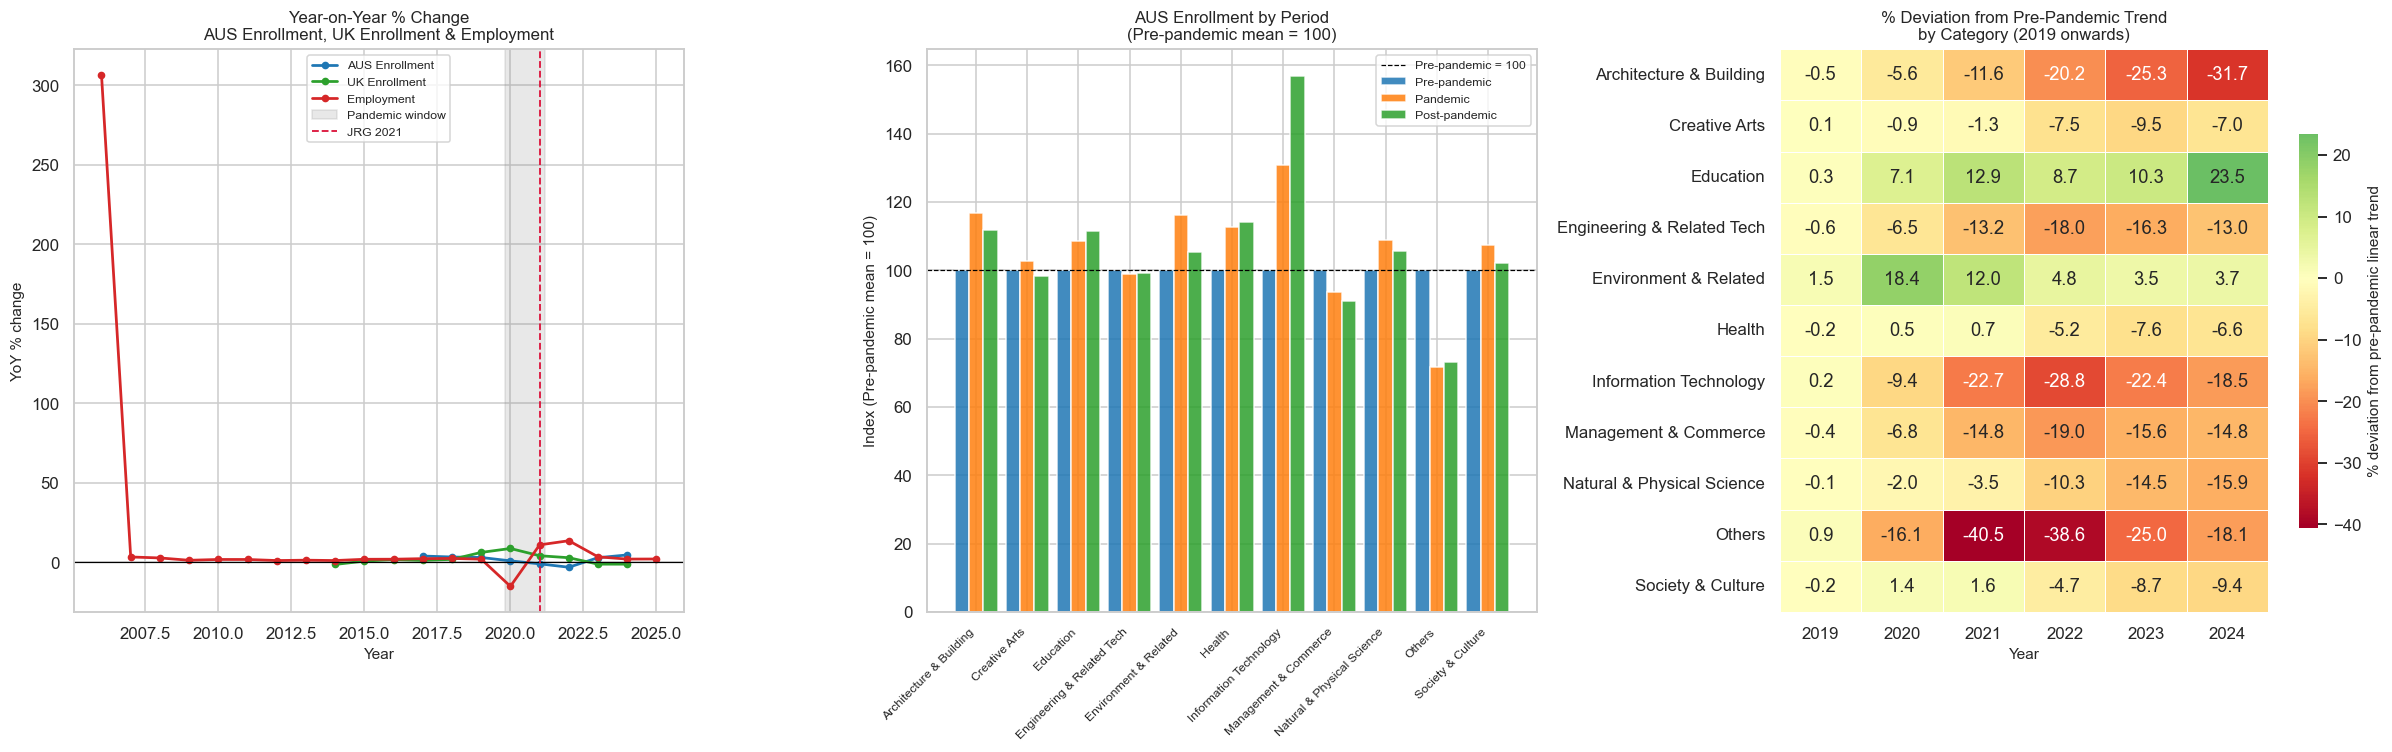

**Table 10.1 — Mean Enrollments by Period (AUS)**

Period,Pre-pandemic,Pandemic,Post-pandemic
Category,,,
Architecture & Building,37377.0,43626.0,41814.0
Creative Arts,95636.0,98136.0,94017.0
Education,127610.0,138610.0,142220.0
Engineering & Related Tech,117045.0,115580.0,115988.0
Environment & Related,18400.0,21346.0,19379.0
Health,251035.0,282988.0,286482.0
Information Technology,90764.0,118606.0,142332.0
Management & Commerce,391764.0,366466.0,356560.0
Natural & Physical Science,126814.0,138181.0,133780.0


In [11]:
# ── YoY % change series ───────────────────────────────────────────────────────
aus_total = aus_long.groupby('Year', as_index=False)['Enrollments'].sum().sort_values('Year')
uk_total = uk_long.groupby('Year', as_index=False)['Total UK'].sum().sort_values('Year')
emp_annual = employment_long.groupby('Year', as_index=False)['Employment'].sum().sort_values('Year')

aus_yoy = aus_total.set_index('Year')['Enrollments'].pct_change() * 100
uk_yoy = uk_total.set_index('Year')['Total UK'].pct_change() * 100
emp_yoy = emp_annual.set_index('Year')['Employment'].pct_change() * 100

# ── Before / During / After (AUS by category) ─────────────────────────────────
def period_label(yr):
    if yr < 2020:
        return 'Pre-pandemic'
    elif yr <= 2021:
        return 'Pandemic'
    else:
        return 'Post-pandemic'

aus_long_p = aus_long.copy()
aus_long_p['Period'] = aus_long_p['Year'].map(period_label)
period_means = aus_long_p.groupby(['Category', 'Period'])['Enrollments'].mean().unstack('Period')
for col in ['Pre-pandemic', 'Pandemic', 'Post-pandemic']:
    if col not in period_means.columns:
        period_means[col] = np.nan
period_means = period_means[['Pre-pandemic', 'Pandemic', 'Post-pandemic']]
period_idx = period_means.div(period_means['Pre-pandemic'], axis=0) * 100

# ── Deviation from pre-pandemic linear trend ──────────────────────────────────
cat_pivot = aus_long.pivot_table(
    index='Year', columns='Category', values='Enrollments', aggfunc='sum'
).sort_index()

deviation = {}
for cat in cat_pivot.columns:
    pre = cat_pivot[cat][cat_pivot.index < 2020].dropna()
    if len(pre) < 2:
        continue
    x_pre = pre.index.to_numpy(dtype=float)
    coeffs = np.polyfit(x_pre, pre.values, 1)
    projected = pd.Series(np.polyval(coeffs, cat_pivot.index.to_numpy(dtype=float)),
                          index=cat_pivot.index)
    deviation[cat] = ((cat_pivot[cat] - projected) / projected * 100)
deviation_df = pd.DataFrame(deviation)
deviation_post = deviation_df[deviation_df.index >= 2019]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: YoY % change ──────────────────────────────────────────────────────
for series, label, color in [
    (aus_yoy, 'AUS Enrollment', '#1f77b4'),
    (uk_yoy,  'UK Enrollment',  '#2ca02c'),
    (emp_yoy, 'Employment',     '#d62728'),
]:
    s = series.dropna()
    axes[0].plot(s.index, s.values, marker='o', markersize=4,
                 label=label, color=color, linewidth=1.8)
axes[0].axvspan(2019.8, 2021.2, color='grey', alpha=0.18, label='Pandemic window')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(JRG_YEAR, color='crimson', linestyle='--', linewidth=1.2, label='JRG 2021')
axes[0].set_title('Year-on-Year % Change\nAUS Enrollment, UK Enrollment & Employment')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('YoY % change')
axes[0].legend(fontsize=8)

# ── Plot 2: Before / During / After indexed bar chart ─────────────────────────
x = np.arange(len(period_idx))
width = 0.28
period_colors = {'Pre-pandemic': '#1f77b4', 'Pandemic': '#ff7f0e', 'Post-pandemic': '#2ca02c'}
for j, period in enumerate(['Pre-pandemic', 'Pandemic', 'Post-pandemic']):
    axes[1].bar(x + j * width, period_idx[period], width, label=period,
                color=period_colors[period], alpha=0.85, edgecolor='white')
axes[1].axhline(100, color='black', linestyle='--', linewidth=0.8, label='Pre-pandemic = 100')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(period_idx.index, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Index (Pre-pandemic mean = 100)')
axes[1].set_title('AUS Enrollment by Period\n(Pre-pandemic mean = 100)')
axes[1].legend(fontsize=8)

# ── Plot 3: % deviation from pre-pandemic trend ───────────────────────────────
sns.heatmap(
    deviation_post.T, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.4, ax=axes[2],
    cbar_kws={'label': '% deviation from pre-pandemic linear trend', 'shrink': 0.7}
)
axes[2].set_title('% Deviation from Pre-Pandemic Trend\nby Category (2019 onwards)')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

display(Markdown('**Table 10.1 — Mean Enrollments by Period (AUS)**'))
display(period_means.round(0))